# 01. EDA — ESS 배터리 수명 (Batch 1·2·3)

**목표** : 5개 질문에 대해 Batch 1·2·3을 같은 그래프 위에서 비교하고, Regression(초기 100 사이클 → `cycle_life`) 모델 전략의 근거를 만든다.

각 질문의 흐름 : **목적 → 어떻게 해결 → 변경 전/후 차이 → 시사점 & 모델링 연결**

- 데이터 로딩·정제 로직 : `src/preprocess.py` · 피처 계산 : `src/features.py`
- 결과 : `results/01_EDA/figs/*.png`, `results/01_EDA/log.txt` (보고서 수치 근거)
- 원논문 수치(Severson et al., *Nature Energy* 2019)와 나란히 출력해서 재현 여부를 확인한다.
- 그래프 라벨은 코랩 한글 폰트 문제를 피하려고 영어로 표기한다.

In [ ]:
# 0. 환경 설정 — Drive에 올려둔 프로젝트 폴더에서 실행
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK_DIR = '/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project'
    # src/ 가 바로 들어있는 폴더를 프로젝트 루트로 사용
    PROJECT_DIR = WORK_DIR if os.path.isdir(f'{WORK_DIR}/src') else f'{WORK_DIR}/ess-battery-project'
    assert os.path.isdir(f'{PROJECT_DIR}/src'), f'src 폴더를 찾지 못했습니다 : {PROJECT_DIR}'
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'], check=False)
else:
    PROJECT_DIR = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
print('PROJECT_DIR :', PROJECT_DIR, '| src 존재 :', os.path.isdir('src'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project | src 존재 : True


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

from src.utils import Reporter, BATCHES, BCOLOR, batch_legend
from src.preprocess import (build_dataset, get_dataset, NOMINAL, EOL_Q, EOL_TOL, rolling_med,
                            PAPER_B1_DROP, PAPER_CONT, PAPER_B3_NOISY)
from src.features import build_feature_table, dq_curve, degradation_table, corr_by_batch, vif, usable_features, ALL_FEATS

R = Reporter('01_EDA')
LONG_TH, SHORT_TH = 1000, 500

## 0. 데이터 로딩
처음 실행하면 `kagglehub`로 약 8GB를 내려받고 `h5py`로 필요한 필드만 읽어 `data/processed/dataset.pkl`로 저장한다.
진단·정제는 `get_dataset()`이 매번 다시 계산하므로, 정제 기준을 바꿔도 다시 다운로드할 필요가 없다.

In [ ]:
build_dataset()
ds = get_dataset()
meta_raw, summ_raw, meta, summ = ds['meta_raw'], ds['summ_raw'], ds['meta'], ds['summ']
R.log('원본 셀 수 :', meta_raw.groupby('batch').size().to_dict(), '| 정제 후 :', meta.groupby('batch').size().to_dict())
R.log('정책 파싱 실패 :', meta_raw[meta_raw['C1'].isna()]['policy'].unique().tolist())
R.log('셀 구조(structure) :', meta_raw.groupby(['batch', 'structure']).size().to_dict())

이미 파싱된 데이터가 있습니다 → /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/data/processed/dataset.pkl
원본 셀 수 : {'B1': 46, 'B2': 47, 'B3': 46} | 정제 후 : {'B1': 41, 'B2': 39, 'B3': 40}
정책 파싱 실패 : ['VarCharge-2C-100cycles', 'VarCharge-4C-100cycles', 'VarCharge-6C-100cycles', 'VarCharge-8C-100cycles']
셀 구조(structure) : {('B1', 'old'): 46, ('B2', 'new'): 9, ('B2', 'old'): 38, ('B3', 'new'): 46}


## 0-1. 원본 데이터 품질 진단 (정제 **전**)

**목적** : 정제 기준을 "논문이 그렇게 했으니까"가 아니라 **데이터에서 보이는 근거**로 정한다.

1. 더미 행 : `QD = 0`인 행 (측정 시작 전 빈 사이클)
2. 스파이크 : 셀별 이동 중앙값에서 크게 벗어난 `QD`
3. **중도 종료(censored) 셀** : 실험이 끝날 때까지 EOL(0.88 Ah)에 도달하지 않은 셀 → `cycle_life`가 실제 수명이 아님
4. **비표준 실험** : 고정 충전 정책이 아닌 셀(VarCharge, SLOWCYCLE)
5. **셀 구조** : 정책 이름에 `newstructure`가 붙은 셀 (Batch 2 일부, Batch 3 전체)
6. 노이즈 · 온도 센서 이상 · IR 측정 누락(IR = 0)

In [ ]:
R.section('0-1. 원본 데이터 품질 진단 (정제 전)')
tbl = meta_raw.groupby('batch').agg(
    cells=('policy', 'size'), policies=('policy', 'nunique'),
    new_structure=('structure', lambda s: int((s == 'new').sum())),
    nonstandard=('nonstandard', 'sum'),
    cycle_life_nan=('cycle_life', lambda s: int(s.isna().sum())),
    censored=('reached_EOL', lambda s: int((~s).sum())),
    zero_rows=('zero_rows', 'sum'), spikes=('spikes', 'sum'),
    IR_zero_cells=('IR_zero', lambda s: int((s > 0).sum())),
    temp_suspect=('temp_suspect', 'sum'),
    init_QD_med=('init_QD', 'median'))
R.table(tbl, '배치별 원본 상태 요약')
R.table(meta_raw[~meta_raw['reached_EOL']][['batch', 'policy', 'cycle_life', 'n_cycles', 'init_QD', 'min_QD']],
        f'중도 종료(EOL 미도달 : 최소 용량 > {EOL_Q + EOL_TOL:.3f} Ah) 셀')
R.table(meta_raw[meta_raw['nonstandard']][['batch', 'policy', 'cycle_life', 'n_cycles', 'min_QD']], '비표준 실험 셀')
R.table(meta_raw[meta_raw['temp_suspect']][['batch', 'policy', 'T_range_early', 'Tavg_early', 'T_range_early_z', 'Tavg_early_z']],
        '온도 센서 이상 후보 (논문 : 4개 셀)')
R.log('\nIR = 0 이 있는 셀 :', meta_raw[meta_raw['IR_zero'] > 0].index.tolist())


0-1. 원본 데이터 품질 진단 (정제 전)

[배치별 원본 상태 요약]
       cells  policies  new_structure  nonstandard  cycle_life_nan  censored  zero_rows  spikes  IR_zero_cells  temp_suspect  init_QD_med
batch                                                                                                                                    
B1        46        23              0            0               0        10         46      24             15             2        1.081
B2        47        20              9            8               8         4          0      24              7             1        1.095
B3        46         8             46            0               2         2          0       2              0             0        1.068

[중도 종료(EOL 미도달 : 최소 용량 > 0.885 Ah) 셀]
      batch                       policy  cycle_life  n_cycles  init_QD  min_QD
cell                                                                           
b1c0     B1               3.6C(80%)-3.6C        1852      1189    1.0

## 0-2. 정제 근거 검증

원논문 공개 코드(`Load Data.ipynb`)의 정제 기준을 이 데이터에 대입해 본다.

| 처리 | 대상 | 논문 코드의 설명 |
|---|---|---|
| 제거 | b1c8, b1c10, b1c12, b1c13, b1c22 | 80% 용량에 도달하지 않음 |
| 병합 | b1c0~b1c4 ← b2c7, b2c8, b2c9, b2c15, b2c16 | Batch 1 실험이 **2017-06-30 배치**에서 이어짐 (+662, 981, 1060, 208, 482 cycles) |
| 제거 | b3c2, b3c23, b3c32, b3c37, b3c42, b3c43 | noisy channels |

**확인할 점** : 이 과제의 Batch 2 파일은 `2018-02-20`이다. 논문의 Batch 2(`2017-06-30`)와 같은 실험이라면, 병합 대상 B2 셀은 ① B1 셀과 같은 정책이고 ② B1 셀의 마지막 용량에서 이어서 시작해야 한다.


0-2. 정제 근거 검증

[논문 병합 쌍 검증 : 같은 정책? B1 마지막 용량 ≈ B2 시작 용량?]
     b1     b2       policy_b1                    policy_b2  same_policy  b1_last_QD  b2_first_QD  b2_life  paper_add
0  b1c0   b2c7  3.6C(80%)-3.6C  4.8C(80%)-4.8C-newstructure        False       1.026        1.091      777        662
1  b1c1   b2c8  3.6C(80%)-3.6C    5.2C(58%)-4C-newstructure        False       1.039        1.091      904        981
2  b1c2   b2c9  3.6C(80%)-3.6C  5.6C(26%)-4.5C-newstructure        False       1.044        1.098      791       1060
3  b1c3  b2c15      4C(80%)-4C                  3.6C(9%)-5C        False      0.9714         1.07      396        208
4  b1c4  b2c16      4C(80%)-4C               4.8C(80%)-4.8C        False       1.022        1.097      472        482
  → 같은 정책 0/5쌍, B2 시작 용량 중앙값 1.091 Ah (B2 전체 초기 용량 중앙값 1.095)
  → 이어진 실험의 흔적이 없음 : 2018-02-20 파일은 논문의 Batch 2(2017-06-30)가 아니다. 곡선 이어붙이기는 하지 않고,
     b1c0~4에는 논문이 보고한 최종 수명(기존 + 이어진 사이클)만 라벨로 사용한다 (곡선은 EOL 전까지만 관측).

[Batch 1 중도 종료 

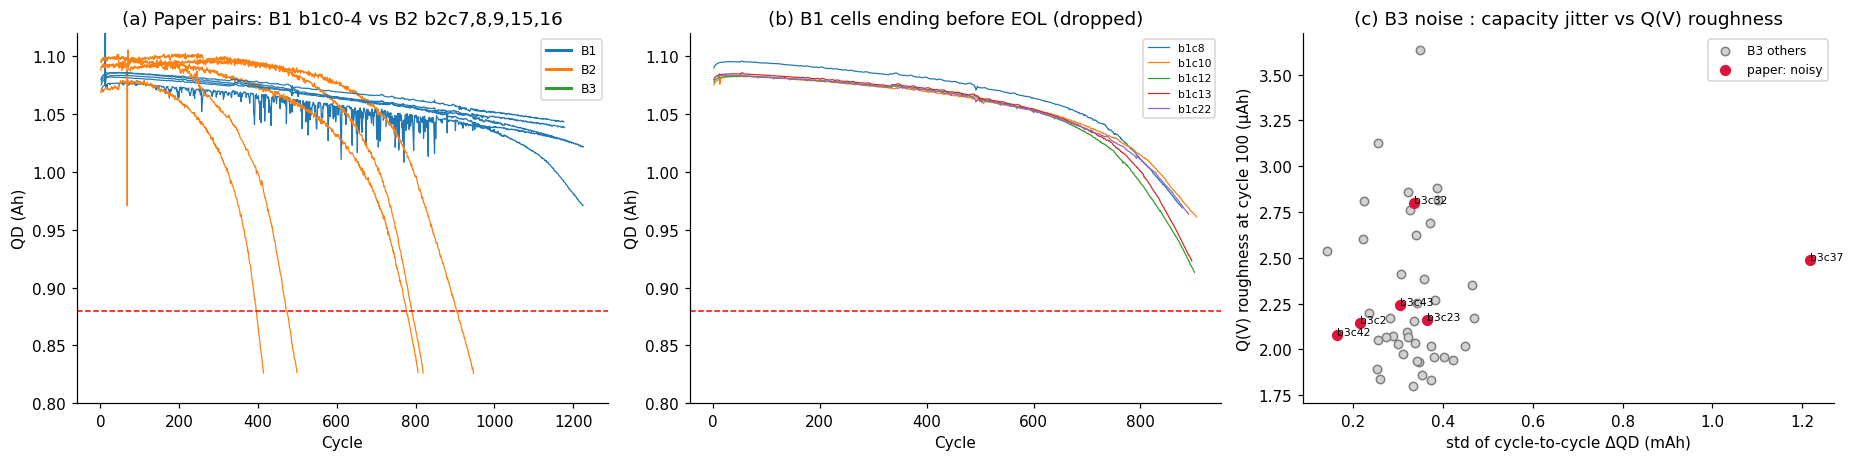


[제외 사유별 셀 수]
                             cells
batch drop_reason                 
B1    censored / no label        5
B2    non-standard protocol      8
B3    censored / no label        2
      paper: noisy channel       4
라벨을 논문 값으로 사용한 셀 : ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4']
사이클 행 : 116,722 → 98,542
정제 후 셀 수 : {'B1': 41, 'B2': 39, 'B3': 40} → 총 120 (논문 : 41 + 43 + 40 = 124, 단 논문의 Batch 2는 다른 파일)


In [ ]:
R.section('0-2. 정제 근거 검증')
rows = []
for b1c, (b2c, add) in PAPER_CONT.items():
    if b1c in meta_raw.index and b2c in meta_raw.index:
        rows.append(dict(b1=b1c, b2=b2c, policy_b1=meta_raw.at[b1c, 'policy'], policy_b2=meta_raw.at[b2c, 'policy'],
                         same_policy=meta_raw.at[b1c, 'policy_base'] == meta_raw.at[b2c, 'policy_base'],
                         b1_last_QD=meta_raw.at[b1c, 'final_QD'], b2_first_QD=meta_raw.at[b2c, 'init_QD'],
                         b2_life=meta_raw.at[b2c, 'cycle_life'], paper_add=add))
pair = pd.DataFrame(rows)
R.table(pair, '논문 병합 쌍 검증 : 같은 정책? B1 마지막 용량 ≈ B2 시작 용량?')
R.log(f'  → 같은 정책 {int(pair.same_policy.sum())}/{len(pair)}쌍, B2 시작 용량 중앙값 {pair.b2_first_QD.median():.3f} Ah '
      f'(B2 전체 초기 용량 중앙값 {meta_raw[meta_raw.batch == "B2"].init_QD.median():.3f})')
if pair.same_policy.sum() == 0:
    R.log('  → 이어진 실험의 흔적이 없음 : 2018-02-20 파일은 논문의 Batch 2(2017-06-30)가 아니다. 곡선 이어붙이기는 하지 않고,')
    R.log('     b1c0~4에는 논문이 보고한 최종 수명(기존 + 이어진 사이클)만 라벨로 사용한다 (곡선은 EOL 전까지만 관측).')
R.table(meta_raw.loc[[c for c in list(PAPER_CONT) + PAPER_B1_DROP if c in meta_raw.index],
                     ['policy', 'cycle_life', 'n_cycles', 'min_QD', 'reached_EOL']], 'Batch 1 중도 종료 셀')

b3 = meta_raw[meta_raw['batch'] == 'B3'].copy()
for col in ['jitter', 'qv_rough', 'spikes']:
    b3[f'{col}_rank'] = b3[col].rank(ascending=False, method='min')
R.table(b3.loc[[c for c in PAPER_B3_NOISY if c in b3.index],
               ['policy', 'cycle_life', 'reached_EOL', 'jitter', 'jitter_rank', 'qv_rough', 'qv_rough_rank', 'spikes']],
        f'Batch 3 논문 노이즈 채널의 노이즈 순위 ({len(b3)}셀 중, 1 = 최대)')

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
ax = axes[0]
for b1c, (b2c, _) in PAPER_CONT.items():
    if b1c in meta_raw.index:
        g1 = summ_raw[(summ_raw.cell == b1c) & (summ_raw.QD > 0.5)]
        ax.plot(g1.cycle, g1.QD, color=BCOLOR['B1'], lw=.8)
    if b2c in meta_raw.index:
        g2 = summ_raw[(summ_raw.cell == b2c) & (summ_raw.QD > 0.5)]
        ax.plot(g2.cycle, g2.QD, color=BCOLOR['B2'], lw=.8)
ax.axhline(EOL_Q, color='red', ls='--', lw=1)
ax.set(title='(a) Paper pairs: B1 b1c0-4 vs B2 b2c7,8,9,15,16', xlabel='Cycle', ylabel='QD (Ah)', ylim=(0.8, 1.12))
batch_legend(ax, fontsize=8)
ax = axes[1]
for c in PAPER_B1_DROP:
    if c in meta_raw.index:
        g = summ_raw[(summ_raw.cell == c) & (summ_raw.QD > 0.5)]
        ax.plot(g.cycle, g.QD, lw=.8, label=c)
ax.axhline(EOL_Q, color='red', ls='--', lw=1)
ax.set(title='(b) B1 cells ending before EOL (dropped)', xlabel='Cycle', ylabel='QD (Ah)', ylim=(0.8, 1.12)); ax.legend(fontsize=7)
ax = axes[2]
ax.scatter(b3['jitter'], b3['qv_rough'], color='lightgray', edgecolor='gray', s=30, label='B3 others')
flag = b3.loc[[c for c in PAPER_B3_NOISY if c in b3.index]]
ax.scatter(flag['jitter'], flag['qv_rough'], color='crimson', s=40, label='paper: noisy')
for c, r in flag.iterrows():
    ax.annotate(c, (r['jitter'], r['qv_rough']), fontsize=7)
ax.set(title='(c) B3 noise : capacity jitter vs Q(V) roughness', xlabel='std of cycle-to-cycle ΔQD (mAh)', ylabel='Q(V) roughness at cycle 100 (µAh)')
ax.legend(fontsize=8)
plt.tight_layout(); R.savefig('00_cleaning_evidence')

R.table(meta_raw[meta_raw.drop_reason != ''].groupby(['batch', 'drop_reason']).size().to_frame('cells'), '제외 사유별 셀 수')
R.log('라벨을 논문 값으로 사용한 셀 :', meta[meta.label_source != 'data'].index.tolist())
R.log('사이클 행 :', f'{len(summ_raw):,} → {len(summ):,}')
R.log('정제 후 셀 수 :', meta.groupby('batch').size().to_dict(), '→ 총', len(meta), '(논문 : 41 + 43 + 40 = 124, 단 논문의 Batch 2는 다른 파일)')

> **배치 간 실험 조건 차이** : 논문 Methods에 따르면 휴지(rest) 시간이 배치마다 다르다 (2017-05-12 : 1분/1초, 2017-06-30 : 5분, 2018-04-12 : 5초 + 방전 전후 내부저항 측정).
> 이 과제의 Batch 2(2018-02-20)는 논문에 없는 배치라 조건을 문서로 확인할 수 없으므로, 아래 Q1·Q4·Q5에서 **데이터로** 배치 차이를 확인한다.
> 특히 `newstructure` 셀은 Batch 1에는 하나도 없고 Batch 2 일부와 Batch 3 전체에만 있다.

## Q1. Cycle Life 분포는 어떻게 생겼는가?

**목적** : 예측 대상 `cycle_life`의 범위·치우침·배치 간 차이를 확인해서 ① 타깃 변환 필요 여부 ② Batch 1 학습 → Batch 2·3 테스트가 같은 분포인지 ③ 유독 짧은 셀이 왜 짧은지 판단한다.

**어떻게 해결** : 정제 전/후 히스토그램(배치별 색) → 장/단수명 비율 → 로그 변환 전/후 정규성 → 배치 간 분포 검정(Kruskal-Wallis, Mann-Whitney, KS) → IQR 이상치 셀의 특성 비교.


Q1. Cycle Life 분포

[정제 전]
       count  mean  median   std  min  max  skew  long_%(>1000)  short_%(<500)
batch                                                                         
B1        46 844.7   858.5 184.6  534 1227 0.438          21.74              0
B2        39 565.7     472 222.2  392 1186 1.573          7.692          71.79
B3        44  1060    1006 313.9  541 1935 1.212          52.27              0

[정제 후]
       count  mean  median   std  min  max  skew  long_%(>1000)  short_%(<500)
batch                                                                         
B1        41 921.3     842 400.8  534 2237 2.063          24.39              0
B2        39 565.7     472 222.2  392 1186 1.573          7.692          71.79
B3        40  1032   964.5 308.6  541 1935 1.466           47.5              0
전체(정제 후) : n=120, 범위 392~2237, 평균 843, 표준편차 375  ← 논문 : 124셀, 150~2300, 평균 806, 표준편차 377


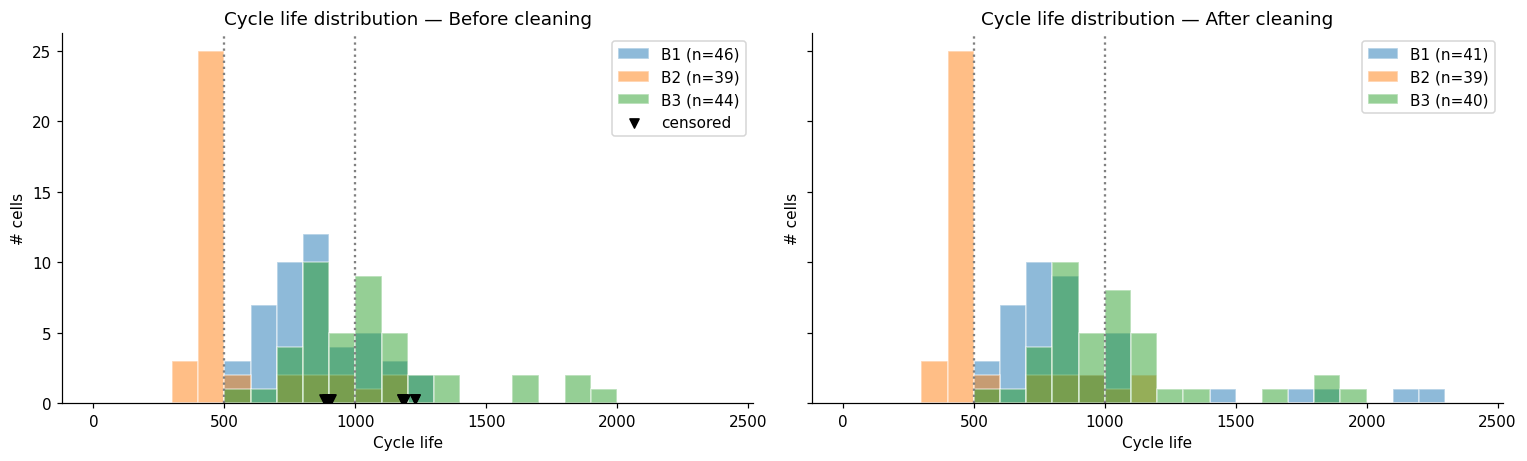

In [ ]:
R.section('Q1. Cycle Life 분포')
meta_before = meta_raw[meta_raw['cycle_life_raw'].notna()].assign(cycle_life=lambda d: d['cycle_life_raw'])   # 원본 라벨 그대로


def life_stats(m):
    g = m.groupby('batch')['cycle_life']
    t = g.agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    t['skew'] = g.apply(lambda s: stats.skew(s))
    t['long_%(>1000)'] = g.apply(lambda s: (s > LONG_TH).mean() * 100)
    t['short_%(<500)'] = g.apply(lambda s: (s < SHORT_TH).mean() * 100)
    return t


R.table(life_stats(meta_before), '정제 전')
R.table(life_stats(meta), '정제 후')
R.log(f'전체(정제 후) : n={len(meta)}, 범위 {meta.cycle_life.min():.0f}~{meta.cycle_life.max():.0f}, '
      f'평균 {meta.cycle_life.mean():.0f}, 표준편차 {meta.cycle_life.std():.0f}  ← 논문 : 124셀, 150~2300, 평균 806, 표준편차 377')

bins = np.arange(0, 2500, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), sharey=True)
for ax, m, ttl in [(axes[0], meta_before, 'Before cleaning'), (axes[1], meta, 'After cleaning')]:
    for b in BATCHES:
        ax.hist(m.loc[m.batch == b, 'cycle_life'], bins=bins, alpha=.5, color=BCOLOR[b],
                label=f'{b} (n={int((m.batch == b).sum())})', edgecolor='white')
    ax.axvline(SHORT_TH, color='gray', ls=':'); ax.axvline(LONG_TH, color='gray', ls=':')
    ax.set(title=f'Cycle life distribution — {ttl}', xlabel='Cycle life', ylabel='# cells')
cc = meta_before[~meta_before['reached_EOL']]
axes[0].scatter(cc['cycle_life'], np.full(len(cc), 0.3), marker='v', color='k', zorder=5, label='censored')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); R.savefig('Q1_a_hist_before_after')


[정규성 Shapiro-Wilk (정제 후)]
  raw   : skew=1.459, p=6.041e-09
  log10 : skew=0.266, p=0.001151
  B1: raw p=1.906e-07 | log p=0.0002318
  B2: raw p=1.186e-07 | log p=1.303e-06
  B3: raw p=7.156e-05 | log p=0.03072

[배치 간 분포 차이] Kruskal-Wallis H=48.82, p=2.5e-11
  B1 vs B2 : Mann-Whitney p=8.703e-08 | KS D=0.769, p=4.422e-12
  B1 vs B3 : Mann-Whitney p=0.004805 | KS D=0.364, p=0.005107
  B2 vs B3 : Mann-Whitney p=7.589e-10 | KS D=0.769, p=7.658e-12


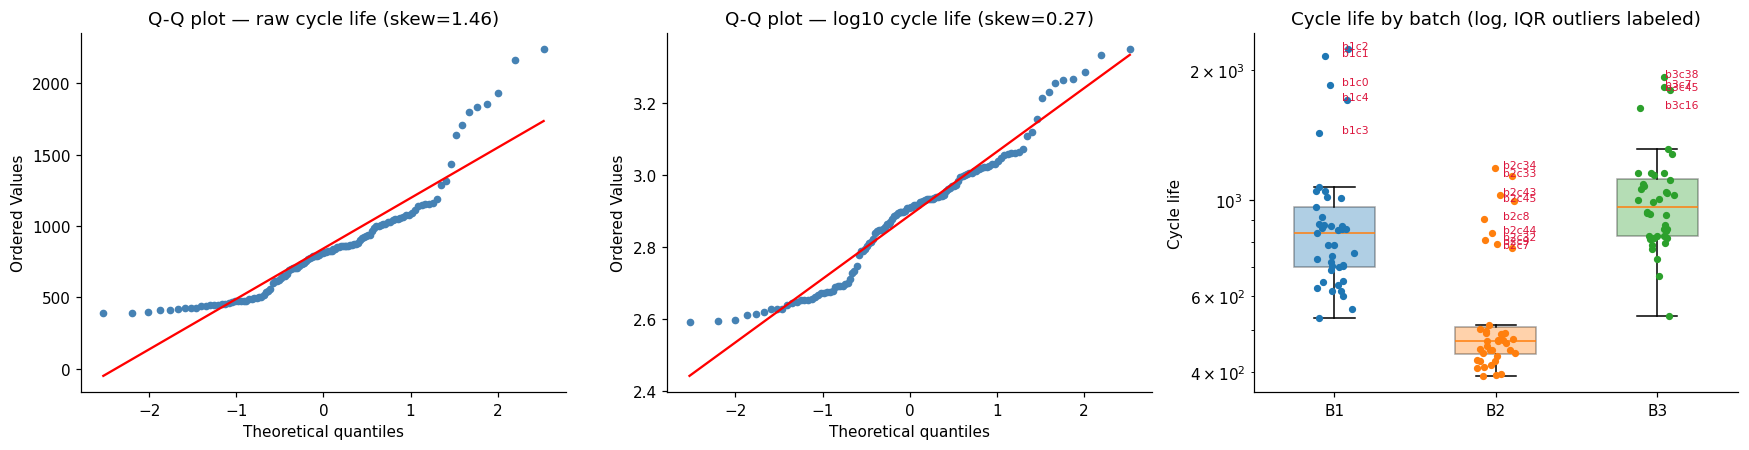

In [ ]:
y = meta['cycle_life']
R.log('\n[정규성 Shapiro-Wilk (정제 후)]')
R.log(f'  raw   : skew={stats.skew(y):.3f}, p={stats.shapiro(y).pvalue:.4g}')
R.log(f'  log10 : skew={stats.skew(np.log10(y)):.3f}, p={stats.shapiro(np.log10(y)).pvalue:.4g}')
for b in BATCHES:
    s = meta.loc[meta.batch == b, 'cycle_life']
    R.log(f'  {b}: raw p={stats.shapiro(s).pvalue:.4g} | log p={stats.shapiro(np.log10(s)).pvalue:.4g}')
groups = [meta.loc[meta.batch == b, 'cycle_life'] for b in BATCHES]
kw = stats.kruskal(*groups)
R.log(f'\n[배치 간 분포 차이] Kruskal-Wallis H={kw.statistic:.2f}, p={kw.pvalue:.4g}')
for a, b in [('B1', 'B2'), ('B1', 'B3'), ('B2', 'B3')]:
    xa, xb = meta.loc[meta.batch == a, 'cycle_life'], meta.loc[meta.batch == b, 'cycle_life']
    R.log(f'  {a} vs {b} : Mann-Whitney p={stats.mannwhitneyu(xa, xb).pvalue:.4g} | KS D={stats.ks_2samp(xa, xb).statistic:.3f}, p={stats.ks_2samp(xa, xb).pvalue:.4g}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, tr, name in [(axes[0], lambda v: v, 'raw'), (axes[1], np.log10, 'log10')]:
    stats.probplot(tr(y), dist='norm', plot=ax)
    ax.get_lines()[0].set(markersize=4, color='steelblue')
    ax.set_title(f'Q-Q plot — {name} cycle life (skew={stats.skew(tr(y)):.2f})')
ax = axes[2]
for k, b in enumerate(BATCHES):
    s = meta.loc[meta.batch == b, 'cycle_life']
    ax.boxplot(s, positions=[k], widths=.5, showfliers=False, patch_artist=True, boxprops=dict(facecolor=BCOLOR[b], alpha=.35))
    ax.scatter(np.full(len(s), k) + np.random.uniform(-.12, .12, len(s)), s, color=BCOLOR[b], s=14, zorder=3)
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    for c, v in s[(s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)].items():
        ax.annotate(c, (k, v), xytext=(5, 0), textcoords='offset points', fontsize=7, color='crimson')
ax.set_xticks(range(3)); ax.set_xticklabels(BATCHES); ax.set_yscale('log')
ax.set(title='Cycle life by batch (log, IQR outliers labeled)', ylabel='Cycle life')
plt.tight_layout(); R.savefig('Q1_b_log_qq_box')


[학습 범위 대비 테스트 셀] B1 수명 범위 = 534 ~ 2237
  B2: B1 최소보다 짧은 셀 30/39 (77%), B1 최대보다 긴 셀 0
  B3: B1 최소보다 짧은 셀 0/40 (0%), B1 최대보다 긴 셀 0

[배치 × 셀 구조별 수명]
                 count  median  min  max
batch structure                         
B1    old           41     842  534 2237
B2    new            9     904  777 1186
      old           30     451  392  514
B3    new           40   964.5  541 1935
  B2 old vs new structure : Mann-Whitney p=7.33e-06


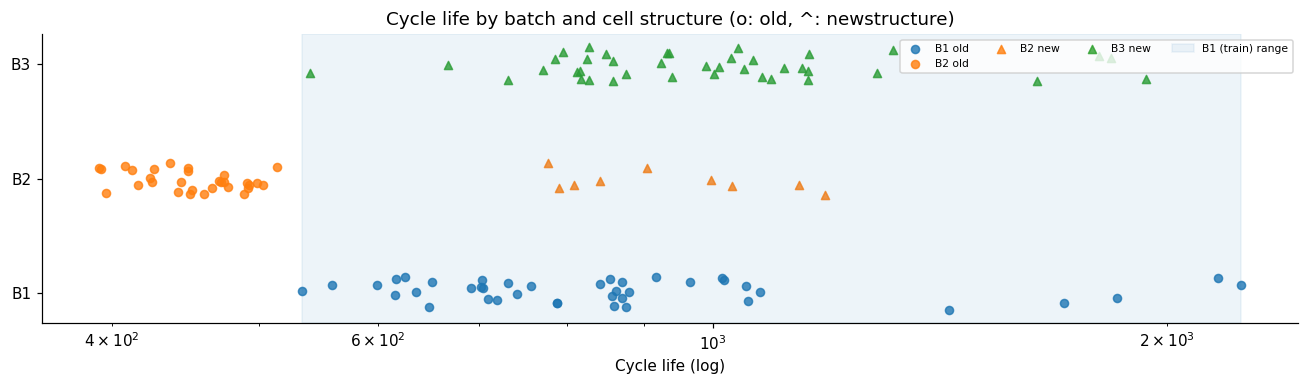

In [ ]:
# 학습(B1) 범위 밖의 테스트 셀 : B1에서 본 적 없는 수명대를 예측해야 하는가?
b1min, b1max = meta.loc[meta.batch == 'B1', 'cycle_life'].agg(['min', 'max'])
R.log(f'\n[학습 범위 대비 테스트 셀] B1 수명 범위 = {b1min:.0f} ~ {b1max:.0f}')
for b in ['B2', 'B3']:
    s = meta.loc[meta.batch == b, 'cycle_life']
    R.log(f'  {b}: B1 최소보다 짧은 셀 {int((s < b1min).sum())}/{len(s)} ({(s < b1min).mean() * 100:.0f}%), '
          f'B1 최대보다 긴 셀 {int((s > b1max).sum())}')
R.table(meta.groupby(['batch', 'structure']).cycle_life.agg(['count', 'median', 'min', 'max']), '배치 × 셀 구조별 수명')
if (meta[meta.batch == 'B2'].structure.nunique() == 2):
    o, n = [meta[(meta.batch == 'B2') & (meta.structure == k)].cycle_life for k in ['old', 'new']]
    R.log(f'  B2 old vs new structure : Mann-Whitney p={stats.mannwhitneyu(o, n).pvalue:.3g}')

fig, ax = plt.subplots(figsize=(12, 3.6))
for k, b in enumerate(BATCHES):
    for st, mk in [('old', 'o'), ('new', '^')]:
        sb = meta[(meta.batch == b) & (meta.structure == st)]
        ax.scatter(sb.cycle_life, np.full(len(sb), k) + np.random.uniform(-.15, .15, len(sb)), color=BCOLOR[b],
                   marker=mk, s=28, alpha=.8, label=f'{b} {st}' if len(sb) else None)
ax.axvspan(b1min, b1max, color=BCOLOR['B1'], alpha=.08, label='B1 (train) range')
ax.set_xscale('log'); ax.set_yticks(range(3)); ax.set_yticklabels(BATCHES)
ax.set(title='Cycle life by batch and cell structure (o: old, ^: newstructure)', xlabel='Cycle life (log)')
ax.legend(fontsize=7, ncol=4, loc='upper right')
plt.tight_layout(); R.savefig('Q1_c_train_range_structure')

In [ ]:
# 이상치 / 단수명 셀은 왜 짧은가?
early = summ[(summ.cycle >= 2) & (summ.cycle <= 100)].groupby('cell').agg(
    QD_early=('QD', 'median'), IR_early=('IR', 'median'), Tmax_early=('Tmax', 'median'), CT_early=('chargetime', 'median'))
m1 = meta.join(early)
outl = []
for b in BATCHES:
    s = m1[m1.batch == b]
    q1, q3 = s.cycle_life.quantile([.25, .75]); iqr = q3 - q1
    outl.append(s[(s.cycle_life < q1 - 1.5 * iqr) | (s.cycle_life > q3 + 1.5 * iqr) | (s.cycle_life < SHORT_TH)])
outl = pd.concat(outl)
cols = ['avgC', 'QD_early', 'IR_early', 'Tmax_early', 'CT_early']
R.table(outl[['batch', 'policy', 'cycle_life'] + cols], '이상치(IQR) 또는 단수명(<500) 셀')
R.table(m1.groupby('batch')[['cycle_life'] + cols].median(), '배치별 중앙값 (비교 기준)')
pct = m1.groupby('batch')[cols].rank(pct=True)
R.table((pct.loc[outl.index] * 100).round(0).join(outl[['batch', 'cycle_life']]), '이상치 셀의 배치 내 백분위(%)')
SHORTEST = meta.cycle_life.idxmin()
R.log(f'\n최단수명 셀 : {SHORTEST} (life={meta.at[SHORTEST, "cycle_life"]:.0f}, {meta.at[SHORTEST, "policy"]}) '
      '← 논문도 "80%에 급격히 도달한 이상 셀 1개"를 별도 표기하고 제외 시 성능을 함께 보고')


[이상치(IQR) 또는 단수명(<500) 셀]
      batch                       policy  cycle_life  avgC  QD_early  IR_early  Tmax_early  CT_early
cell                                                                                                
b1c0     B1               3.6C(80%)-3.6C        1852   3.6     1.076   0.01662       35.36     13.36
b1c1     B1               3.6C(80%)-3.6C        2160   3.6     1.082   0.01692       34.14     13.34
b1c2     B1               3.6C(80%)-3.6C        2237   3.6     1.086   0.01677       34.53     13.34
b1c3     B1                   4C(80%)-4C        1434     4     1.085   0.01631       30.59     12.09
b1c4     B1                   4C(80%)-4C        1709     4     1.083   0.01668       34.34     12.09
b2c0     B2                 5.2C(58%)-4C         477 4.804     1.106   0.01735       35.37     10.17
b2c1     B2               5.6C(26%)-4.5C         491 4.807     1.106   0.01751       36.43     10.18
b2c2     B2              5.2C(50%)-4.25C         424 4.798     1

## Q2. 열화 곡선 — 방전 용량은 어떻게 감소하는가?

**목적** : 용량이 일정한 속도로 줄어드는지, 어느 순간 꺾이는지(knee)를 확인한다. 열화가 후반에 몰려 있다면 **초기 100 사이클의 용량 값만으로는 수명 구분이 어렵다**는 뜻이므로, 더 민감한 신호(Q3 ΔQ(V))가 필요한지 판단한다.

**어떻게 해결** : 정제 전/후 QD 곡선 → 수명 정규화 SOH 곡선(배치별 중앙값) → 수명 구간별 열화 속도 → 2-구간 선형회귀로 knee 탐색 → **논문 Fig. 1 재현** (사이클 2·100 용량, 95~100 기울기와 수명의 상관, 용량비 100:2).


Q2. 열화 곡선


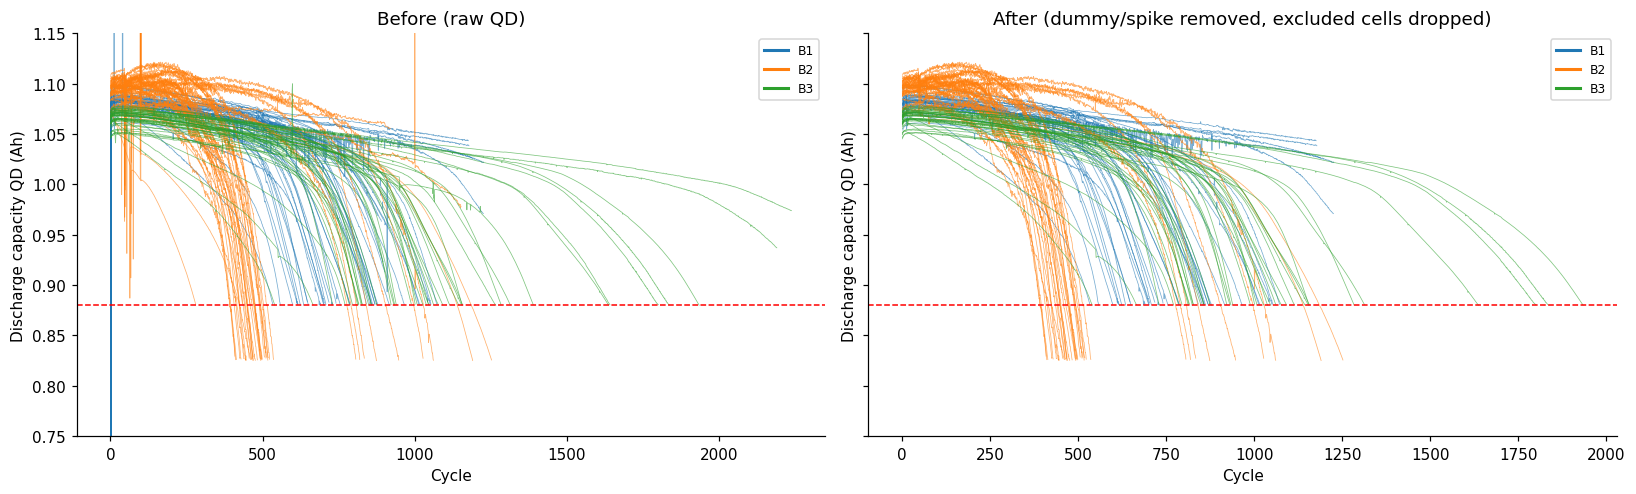

열화 곡선 분석 대상 : 115 셀 (EOL까지 관측되지 않은 셀 제외 : ['b1c0', 'b1c1', 'b1c2', 'b1c3', 'b1c4'] )

[수명 구간별 열화 속도 중앙값 (×1e-4 Ah/cycle)]
       fade_0_20  fade_20_40  fade_40_60  fade_60_80  fade_80_100  accel(last/20-40%)
batch                                                                                
B1        0.2327      0.5384      0.8811       2.401         8.71               16.18
B2       -0.2099      0.4351       1.535       4.569        15.53                35.7
B3         0.237      0.4779      0.6759       1.415        6.623               13.86


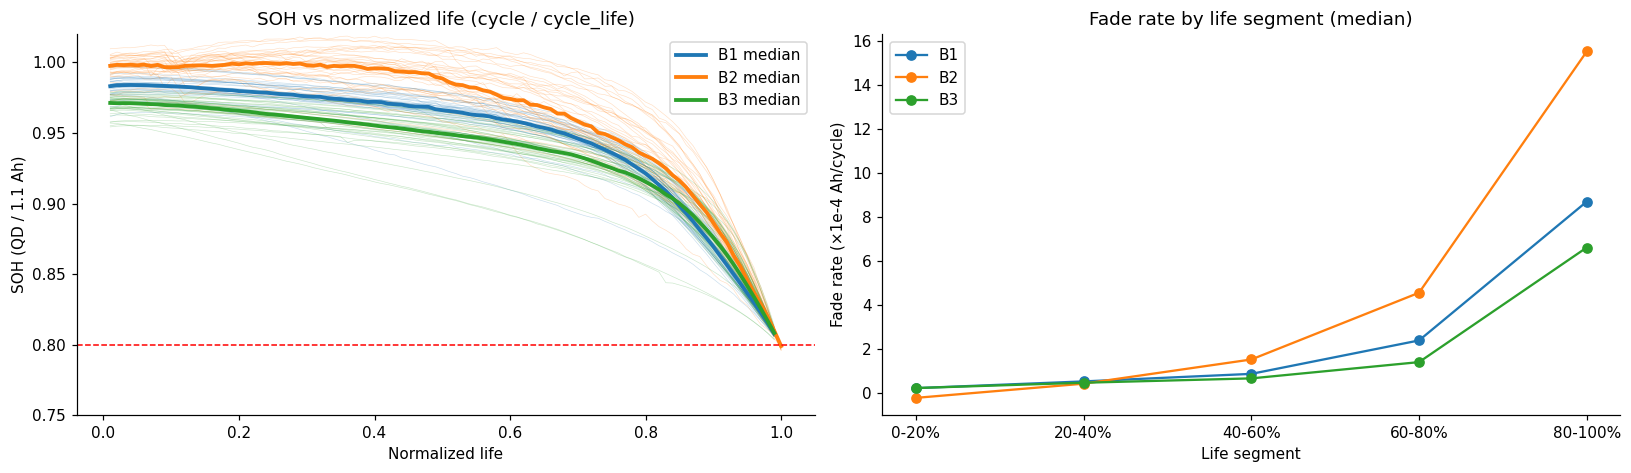

In [ ]:
R.section('Q2. 열화 곡선')
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for ax, df, ttl in [(axes[0], summ_raw, 'Before (raw QD)'), (axes[1], summ, 'After (dummy/spike removed, excluded cells dropped)')]:
    for cid, g in df.groupby('cell', sort=False):
        ax.plot(g.cycle, g.QD, color=BCOLOR[g.batch.iloc[0]], lw=.5, alpha=.6)
    ax.axhline(EOL_Q, color='red', ls='--', lw=1)
    ax.set(title=ttl, xlabel='Cycle', ylabel='Discharge capacity QD (Ah)', ylim=(0.75, 1.15)); batch_legend(ax, fontsize=8)
plt.tight_layout(); R.savefig('Q2_a_qd_before_after')

D, GRID, soh = degradation_table(meta, summ)
meta = meta.join(D)
R.log('열화 곡선 분석 대상 :', len(D), '셀 (EOL까지 관측되지 않은 셀 제외 :', meta.index[~meta.curve_complete].tolist(), ')')
fcols = [c for c in D.columns if c.startswith('fade_')]
fade_med = meta.groupby('batch')[fcols].median()
fade_med['accel(last/20-40%)'] = fade_med[fcols[-1]] / fade_med[fcols[1]]   # 0-20% 구간은 초기 용량 상승으로 음수일 수 있음
R.table(fade_med, '수명 구간별 열화 속도 중앙값 (×1e-4 Ah/cycle)')

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
ax = axes[0]
for cid, c in soh.items():
    ax.plot(GRID, c, color=BCOLOR[meta.at[cid, 'batch']], lw=.4, alpha=.25)
for b in BATCHES:
    mat = np.array([c for cid, c in soh.items() if meta.at[cid, 'batch'] == b])
    ax.plot(GRID, np.nanmedian(mat, 0), color=BCOLOR[b], lw=2.5, label=f'{b} median')
ax.axhline(0.8, color='red', ls='--', lw=1)
ax.set(title='SOH vs normalized life (cycle / cycle_life)', xlabel='Normalized life', ylabel='SOH (QD / 1.1 Ah)', ylim=(0.75, 1.02)); ax.legend()
ax = axes[1]
for b in BATCHES:
    ax.plot(range(len(fcols)), fade_med.loc[b, fcols], marker='o', color=BCOLOR[b], label=b)
ax.set_xticks(range(len(fcols))); ax.set_xticklabels([c.replace('fade_', '').replace('_', '-') + '%' for c in fcols])
ax.set(title='Fade rate by life segment (median)', xlabel='Life segment', ylabel='Fade rate (×1e-4 Ah/cycle)'); ax.legend()
plt.tight_layout(); R.savefig('Q2_b_normalized_fade_rate')


[Knee 위치 / 수명 (knee_ratio)]
       count   mean     std    min    25%    50%    75%    max
batch                                                         
B1        36 0.7543 0.02817 0.6948 0.7409 0.7505 0.7664 0.8203
B2        39 0.7411 0.04549 0.5962 0.7166 0.7482 0.7732 0.8216
B3        40    0.8 0.03692  0.695 0.7791 0.7945 0.8244 0.8676
  B1: knee vs cycle_life r=0.981 (p=6e-26)
  B2: knee vs cycle_life r=0.994 (p=7.6e-38)
  B3: knee vs cycle_life r=0.991 (p=4.8e-35)
  ALL: knee vs cycle_life r=0.993 (p=7.9e-108)


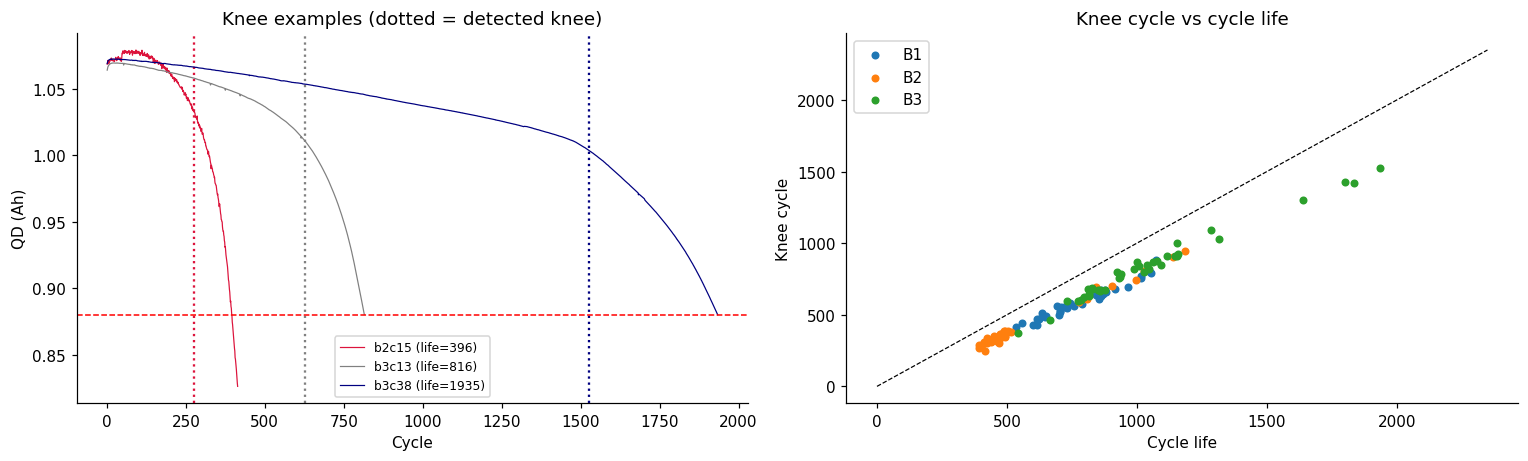

In [ ]:
R.table(meta.groupby('batch')['knee_ratio'].describe(), 'Knee 위치 / 수명 (knee_ratio)')
for b in BATCHES + ['ALL']:
    s = meta if b == 'ALL' else meta[meta.batch == b]
    s = s.dropna(subset=['knee'])
    r = stats.pearsonr(s.knee, s.cycle_life)
    R.log(f'  {b}: knee vs cycle_life r={r[0]:.3f} (p={r[1]:.2g})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
ax = axes[0]
ex = meta.sort_values('cycle_life').index
for cid, col in zip([ex[2], ex[len(ex) // 2], ex[-3]], ['crimson', 'gray', 'navy']):
    g = summ[summ.cell == cid]
    ax.plot(g.cycle, g.QD, color=col, lw=.8, label=f'{cid} (life={meta.at[cid, "cycle_life"]:.0f})')
    ax.axvline(meta.at[cid, 'knee'], color=col, ls=':')
ax.axhline(EOL_Q, color='red', ls='--', lw=1)
ax.set(title='Knee examples (dotted = detected knee)', xlabel='Cycle', ylabel='QD (Ah)'); ax.legend(fontsize=8)
ax = axes[1]
for b in BATCHES:
    s = meta[meta.batch == b]; ax.scatter(s.cycle_life, s.knee, color=BCOLOR[b], s=18, label=b)
lim = [0, meta.cycle_life.max() * 1.05]; ax.plot(lim, lim, 'k--', lw=.8)
ax.set(title='Knee cycle vs cycle life', xlabel='Cycle life', ylabel='Knee cycle'); ax.legend()
plt.tight_layout(); R.savefig('Q2_c_knee')


[논문 Fig.1 재현 : log10(life)와의 Pearson r]
                       paper_r  ours_r  ours_r_excl_shortest    B1_r    B2_r   B3_r
feature                                                                            
QD_2                     -0.06 -0.5221               -0.5182 0.03462 -0.2254 0.2585
QD_100                    0.27 -0.4584               -0.4535  0.2386 -0.2687 0.4075
slope_95_100(mAh/cyc)     0.47  0.1144               0.09068    0.21  0.2048 0.2422
  용량비(100:2) > 1 인 셀 비율 = 80%  ← 논문 81% | 중앙값 변화 = +0.19%  ← 논문 +0.2%


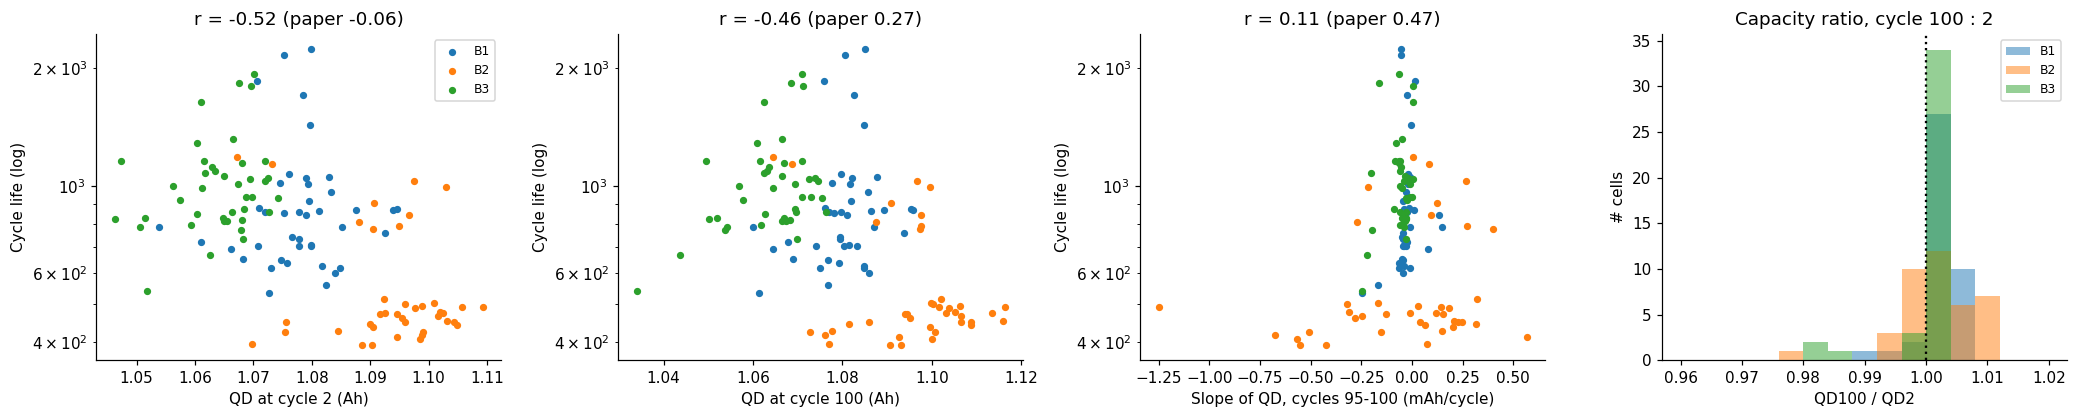

In [ ]:
# 논문 Fig. 1 재현 : 초기 용량 기반 지표는 수명을 잘 설명하지 못한다
def q_at(lo, hi):
    return summ[summ.cycle.between(lo, hi)].groupby('cell').QD.median()

slope95 = summ[summ.cycle.between(95, 100)].groupby('cell').apply(lambda g: np.polyfit(g.cycle, g.QD, 1)[0] * 1e3 if len(g) > 2 else np.nan)
fig1 = pd.DataFrame({'QD_2': q_at(2, 2), 'QD_100': q_at(100, 100), 'slope_95_100(mAh/cyc)': slope95})
fig1['ratio_100_2'] = fig1['QD_100'] / fig1['QD_2']
fig1 = fig1.join(meta[['batch', 'cycle_life']])
fig1['log_life'] = np.log10(fig1['cycle_life'])
paper = {'QD_2': -0.06, 'QD_100': 0.27, 'slope_95_100(mAh/cyc)': 0.47}
rows = []
for f, pv in paper.items():
    s = fig1.dropna(subset=[f])
    s_ex = s.drop(index=SHORTEST, errors='ignore')
    rows.append(dict(feature=f, paper_r=pv, ours_r=stats.pearsonr(s[f], s.log_life)[0],
                     ours_r_excl_shortest=stats.pearsonr(s_ex[f], s_ex.log_life)[0],
                     **{f'{b}_r': stats.pearsonr(s[s.batch == b][f], s[s.batch == b].log_life)[0] for b in BATCHES}))
R.table(pd.DataFrame(rows).set_index('feature'), '논문 Fig.1 재현 : log10(life)와의 Pearson r')
up = (fig1['ratio_100_2'] > 1).mean() * 100
R.log(f'  용량비(100:2) > 1 인 셀 비율 = {up:.0f}%  ← 논문 81% | 중앙값 변화 = {(fig1.ratio_100_2.median() - 1) * 100:+.2f}%  ← 논문 +0.2%')

fig, axes = plt.subplots(1, 4, figsize=(19, 3.9))
for ax, f, xl in zip(axes[:3], paper, ['QD at cycle 2 (Ah)', 'QD at cycle 100 (Ah)', 'Slope of QD, cycles 95-100 (mAh/cycle)']):
    for b in BATCHES:
        s = fig1[fig1.batch == b]; ax.scatter(s[f], s.cycle_life, color=BCOLOR[b], s=14, label=b)
    ax.set_yscale('log'); ax.set(xlabel=xl, ylabel='Cycle life (log)', title=f'r = {stats.pearsonr(fig1.dropna(subset=[f])[f], fig1.dropna(subset=[f]).log_life)[0]:.2f} (paper {paper[f]})')
axes[0].legend(fontsize=8)
ax = axes[3]
for b in BATCHES:
    ax.hist(fig1[fig1.batch == b].ratio_100_2, bins=np.arange(.96, 1.021, .004), alpha=.5, color=BCOLOR[b], label=b)
ax.axvline(1, color='k', ls=':'); ax.set(title='Capacity ratio, cycle 100 : 2', xlabel='QD100 / QD2', ylabel='# cells'); ax.legend(fontsize=8)
plt.tight_layout(); R.savefig('Q2_d_paper_fig1_replication')

## Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?

**목적** : Q2에서 초기 100 사이클의 용량 지표가 수명을 거의 설명하지 못했다면, 같은 전압 구간의 방전 곡선 차이 `ΔQ₁₀₀₋₁₀(V) = Q₁₀₀(V) − Q₁₀(V)`가 **용량이 눈에 띄게 줄기 전에** 수명 신호를 담고 있는지 확인한다.

**어떻게 해결** : 배치별 ΔQ(V) 곡선(수명으로 색칠) → 장/단수명 그룹 비교 → 요약 통계(최소·평균·분산·왜도·첨도·2V 값) → **선형 vs 로그 스케일** 관계 비교 → 논문 Fig. 2c(r = −0.93) 재현.
(어느 사이클 쌍이 최적인지는 `02_feature_engineering`에서 격자 탐색으로 다룬다.)


Q3. ΔQ(V)
ΔQ 계산 불가 셀 : []


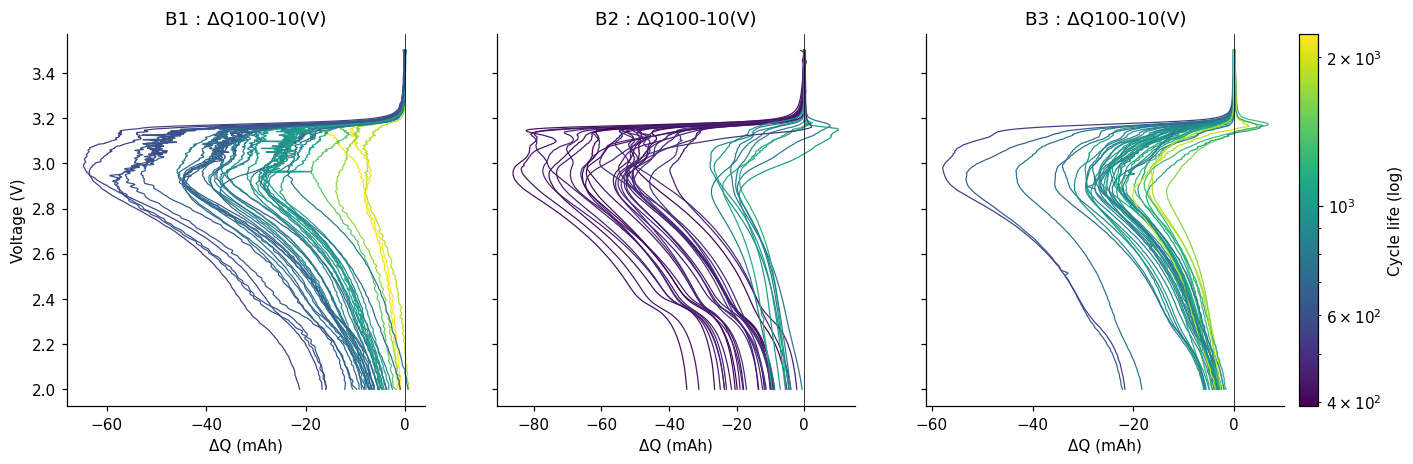

In [ ]:
R.section('Q3. ΔQ(V)')
F = build_feature_table(ds)
meta = meta.join(F[['dq_var', 'dq_min', 'dq_log_var', 'dq_log_absmin', 'dq_mean', 'dq_skew', 'dq_kurt', 'dq_2V']])
dq = {c: dq_curve(ds['qdlin'], c) for c in meta.index}
R.log('ΔQ 계산 불가 셀 :', [c for c, v in dq.items() if v is None])
V = ds['vdlin']
norm = matplotlib.colors.LogNorm(meta.cycle_life.min(), meta.cycle_life.max())
cmap = plt.get_cmap('viridis')
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), sharey=True)
for ax, b in zip(axes, BATCHES):
    for c in meta[meta.batch == b].index:
        if dq[c] is not None:
            ax.plot(dq[c] * 1e3, V, color=cmap(norm(meta.at[c, 'cycle_life'])), lw=.8)
    ax.set(title=f'{b} : ΔQ100-10(V)', xlabel='ΔQ (mAh)'); ax.axvline(0, color='k', lw=.5)
axes[0].set_ylabel('Voltage (V)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='Cycle life (log)', pad=.01)
R.savefig('Q3_a_dq_curves_by_batch')


[배치 × 수명 그룹]
life_grp  short(<500)  mid  long(>1000)
batch                                  
B1                  0   31           10
B2                 28    8            3
B3                  0   21           19

[수명 그룹별 ΔQ 통계 중앙값]
             dq_log_var  dq_log_absmin   dq_mean  dq_skew  dq_kurt     dq_2V
life_grp                                                                    
short(<500)      -3.446          -1.25  -0.02867  0.03256   -1.242  -0.01535
mid              -3.869         -1.458  -0.01557  -0.1775    -1.24 -0.005692
long(>1000)      -4.279         -1.659 -0.009587  -0.2657   -1.138 -0.003761
  log Var(ΔQ) short vs long : Mann-Whitney p=3.34e-11


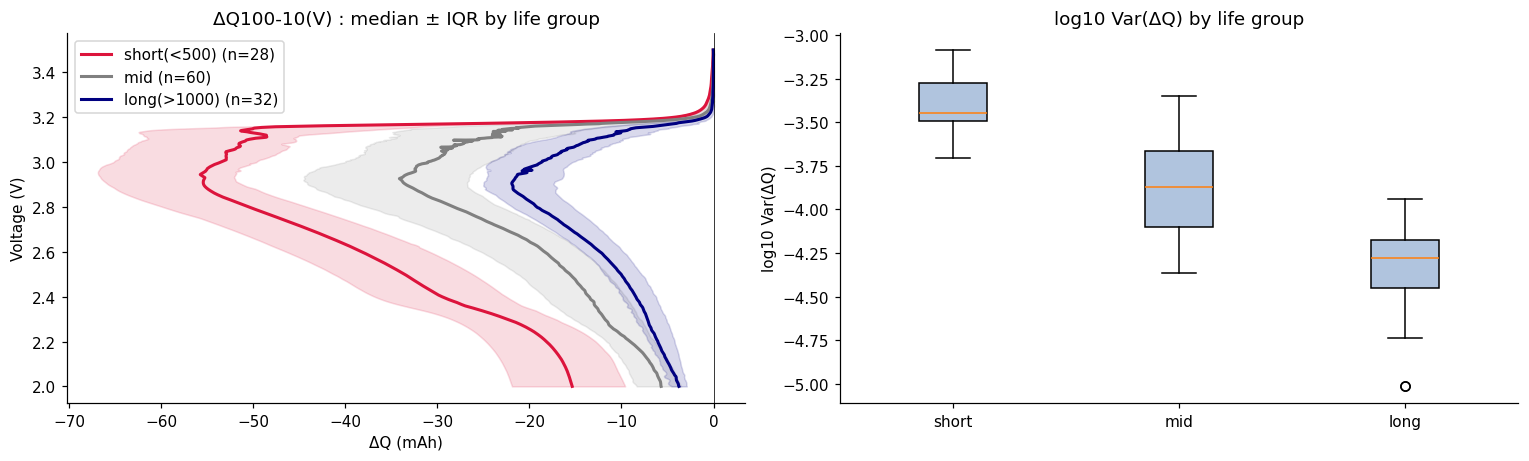

In [ ]:
meta['life_grp'] = pd.cut(meta.cycle_life, [0, SHORT_TH, LONG_TH, 1e5], labels=['short(<500)', 'mid', 'long(>1000)'])
R.table(pd.crosstab(meta.batch, meta.life_grp), '배치 × 수명 그룹')
fcols3 = ['dq_log_var', 'dq_log_absmin', 'dq_mean', 'dq_skew', 'dq_kurt', 'dq_2V']
R.table(meta.groupby('life_grp')[fcols3].median(), '수명 그룹별 ΔQ 통계 중앙값')
sl, lg = meta[meta.life_grp == 'short(<500)'].dq_log_var.dropna(), meta[meta.life_grp == 'long(>1000)'].dq_log_var.dropna()
if len(sl) > 1 and len(lg) > 1:
    R.log(f'  log Var(ΔQ) short vs long : Mann-Whitney p={stats.mannwhitneyu(sl, lg).pvalue:.3g}')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
ax = axes[0]
for grp, col in zip(['short(<500)', 'mid', 'long(>1000)'], ['crimson', 'gray', 'navy']):
    mat = np.array([dq[c] for c in meta[meta.life_grp == grp].index if dq[c] is not None])
    if len(mat):
        ax.plot(np.median(mat, 0) * 1e3, V, color=col, lw=2, label=f'{grp} (n={len(mat)})')
        ax.fill_betweenx(V, np.percentile(mat, 25, 0) * 1e3, np.percentile(mat, 75, 0) * 1e3, color=col, alpha=.15)
ax.axvline(0, color='k', lw=.5); ax.set(title='ΔQ100-10(V) : median ± IQR by life group', xlabel='ΔQ (mAh)', ylabel='Voltage (V)'); ax.legend()
ax = axes[1]
data = [meta[meta.life_grp == g]['dq_log_var'].dropna() for g in ['short(<500)', 'mid', 'long(>1000)']]
ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['short', 'mid', 'long']); ax.set(title='log10 Var(ΔQ) by life group', ylabel='log10 Var(ΔQ)')
plt.tight_layout(); R.savefig('Q3_b_long_vs_short')

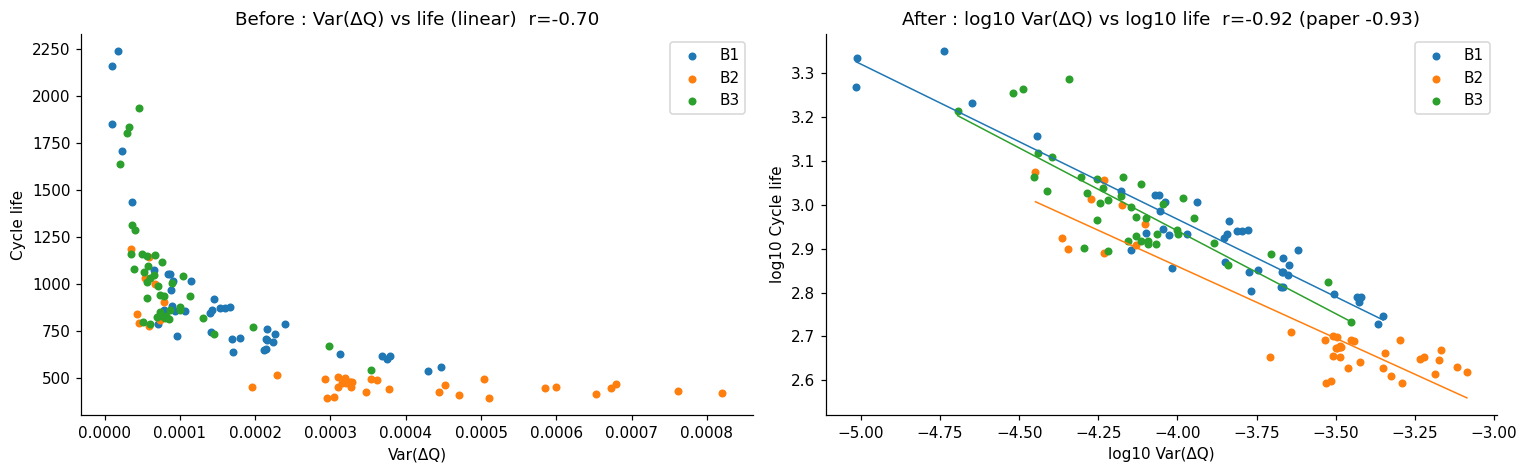


[ΔQ 통계량 vs log10(life) Pearson r]
                   B1      B2      B3     ALL  sign_stable  min_abs_r
dq_log_var     -0.945 -0.9184 -0.8046 -0.9194         True     0.8046
dq_log_absmin -0.9164 -0.9014 -0.8111 -0.9062         True     0.8111
dq_mean        0.8461  0.7907  0.6894   0.845         True     0.6894
dq_skew       -0.6775 -0.1263  -0.291 -0.4807         True     0.1263
dq_kurt        0.4721  0.6525 0.09221  0.3494         True    0.09221
dq_2V          0.6978  0.5288   0.486  0.6918         True      0.486
  선형 r=-0.698 → 로그 r=-0.919 | 최단수명 셀 제외 시 r=-0.918  ← 논문 −0.93 (최단수명 셀 제외)


In [ ]:
s = meta.dropna(subset=['dq_var'])
s_ex = s.drop(index=SHORTEST, errors='ignore')
r_lin = stats.pearsonr(s.dq_var, s.cycle_life)[0]
r_log = stats.pearsonr(s.dq_log_var, np.log10(s.cycle_life))[0]
r_log_ex = stats.pearsonr(s_ex.dq_log_var, np.log10(s_ex.cycle_life))[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for b in BATCHES:
    sb = s[s.batch == b]
    axes[0].scatter(sb.dq_var, sb.cycle_life, color=BCOLOR[b], s=18, label=b)
    axes[1].scatter(sb.dq_log_var, np.log10(sb.cycle_life), color=BCOLOR[b], s=18, label=b)
    p = np.polyfit(sb.dq_log_var, np.log10(sb.cycle_life), 1)
    xx = np.linspace(sb.dq_log_var.min(), sb.dq_log_var.max(), 10); axes[1].plot(xx, np.polyval(p, xx), color=BCOLOR[b], lw=1)
axes[0].set(title=f'Before : Var(ΔQ) vs life (linear)  r={r_lin:.2f}', xlabel='Var(ΔQ)', ylabel='Cycle life'); axes[0].legend()
axes[1].set(title=f'After : log10 Var(ΔQ) vs log10 life  r={r_log:.2f} (paper -0.93)', xlabel='log10 Var(ΔQ)', ylabel='log10 Cycle life'); axes[1].legend()
plt.tight_layout(); R.savefig('Q3_c_linear_vs_log')
rtab = corr_by_batch(meta.assign(log_life=np.log10(meta.cycle_life)), fcols3)
R.table(rtab, 'ΔQ 통계량 vs log10(life) Pearson r')
R.log(f'  선형 r={r_lin:.3f} → 로그 r={r_log:.3f} | 최단수명 셀 제외 시 r={r_log_ex:.3f}  ← 논문 −0.93 (최단수명 셀 제외)')

## Q4. 충전 조건(C-rate)과 수명의 관계는?

**목적** : 정책 문자열을 그대로 쓰면 범주가 많고 배치마다 구성이 달라 일반화가 어렵다. 정책을 **수치(C1, 전환 SOC Q1, C2, 0→80% 평균 C-rate)** 로 분해하면 수명과의 관계가 드러나는지, 고속 충전이 정말 수명을 줄이는지, 그 경로(발열·열화 속도)가 무엇인지, **같은 정책인데 배치가 다르면 수명이 달라지는지** 확인한다.

**어떻게 해결** : 정책 문자열(범주) vs 평균 C-rate(수치) → 실제 충전 전류 프로파일 확인 → C-rate·온도·열화 속도 Spearman 상관 → 같은 정책의 배치 간 수명 비교.


Q4. 충전 조건(C-rate)과 수명
배치별 정책 수 : {'B1': 22, 'B2': 12, 'B3': 8}

[배치별 정책 수치 범위]
       C1             Q1             C2             avgC             
      min median max min median max min median max   min median   max
batch                                                                
B1    3.6      6   8  15     50  80   3    3.6 5.4   3.6  4.402   5.4
B2    3.6    5.2   6   9     50  80   3    4.5   6  4.79    4.8 4.807
B3    3.7    5.3 5.9  15     45  80 3.1    4.3 5.9 4.794  4.802 4.813
avgC 표준편차 : {'B1': 0.426, 'B2': 0.004, 'B3': 0.005} → 표준편차가 0에 가까운 배치는 모든 셀이 같은 시간(약 10분) 안에 80%까지 충전되도록 설계된 것 : 평균 속도가 아니라 충전 "모양"만 다르다


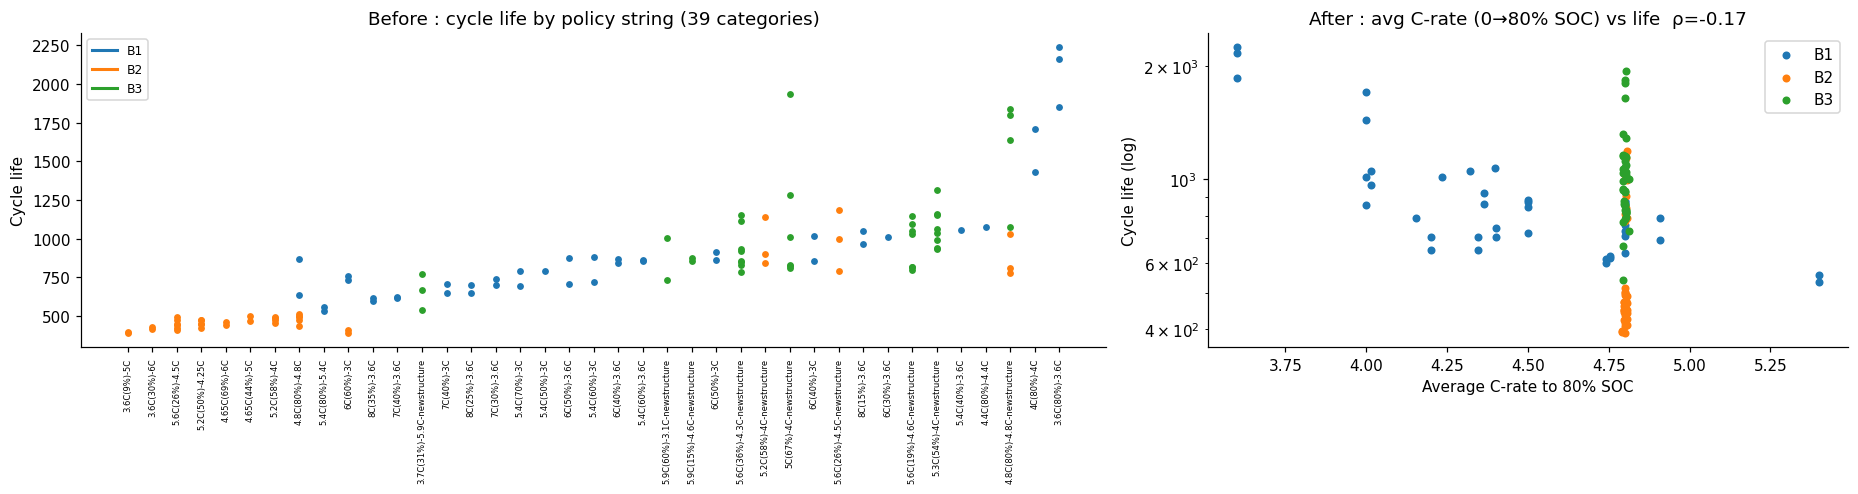


[평균 C-rate vs 수명 Spearman]
  B1: ρ=-0.615, p=1.91e-05
  B2: ρ=0.321, p=0.0465
  B3: ρ=-0.157, p=0.335
  ALL: ρ=-0.166, p=0.0695

[C1 그룹 × 배치 수명 중앙값]
       count         median         
batch     B1  B2  B3     B1  B2   B3
C1_grp                              
C1≤4       5   4   3   1852 406  667
4<C1≤6    24  35  37  855.5 474 1002
C1>6      12   0   0  676.5 NaN  NaN
  C1 그룹 간 Kruskal-Wallis p=0.469


In [ ]:
R.section('Q4. 충전 조건(C-rate)과 수명')
meta = meta.join(early)
meta['log_life'] = np.log10(meta.cycle_life)
R.log('배치별 정책 수 :', meta.groupby('batch').policy.nunique().to_dict())
R.table(meta.groupby('batch')[['C1', 'Q1', 'C2', 'avgC']].agg(['min', 'median', 'max']), '배치별 정책 수치 범위')
R.log('avgC 표준편차 :', meta.groupby('batch').avgC.std().round(3).to_dict(),
      '→ 표준편차가 0에 가까운 배치는 모든 셀이 같은 시간(약 10분) 안에 80%까지 충전되도록 설계된 것 : 평균 속도가 아니라 충전 "모양"만 다르다')

fig, axes = plt.subplots(1, 2, figsize=(17, 4.6), gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
order = meta.groupby('policy').cycle_life.median().sort_values().index
for k, p in enumerate(order):
    sp_ = meta[meta.policy == p]
    for b in BATCHES:
        sb = sp_[sp_.batch == b]; ax.scatter(np.full(len(sb), k), sb.cycle_life, color=BCOLOR[b], s=12)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=90, fontsize=5.5)
ax.set(title=f'Before : cycle life by policy string ({len(order)} categories)', ylabel='Cycle life'); batch_legend(ax, fontsize=8)
ax = axes[1]
for b in BATCHES:
    sb = meta[meta.batch == b]; ax.scatter(sb.avgC, sb.cycle_life, color=BCOLOR[b], s=18, label=b)
rho = stats.spearmanr(meta.avgC, meta.cycle_life, nan_policy='omit').correlation
ax.set_yscale('log'); ax.set(title=f'After : avg C-rate (0→80% SOC) vs life  ρ={rho:.2f}', xlabel='Average C-rate to 80% SOC', ylabel='Cycle life (log)'); ax.legend()
plt.tight_layout(); R.savefig('Q4_a_policy_category_vs_numeric')
R.log('\n[평균 C-rate vs 수명 Spearman]')
for b in BATCHES + ['ALL']:
    sb = meta if b == 'ALL' else meta[meta.batch == b]
    r = stats.spearmanr(sb.avgC, sb.cycle_life, nan_policy='omit')
    R.log(f'  {b}: ρ={r.correlation:.3f}, p={r.pvalue:.3g}')
meta['C1_grp'] = pd.cut(meta.C1, [0, 4, 6, 10], labels=['C1≤4', '4<C1≤6', 'C1>6'])
R.table(meta.groupby(['C1_grp', 'batch']).cycle_life.agg(['count', 'median']).unstack(), 'C1 그룹 × 배치 수명 중앙값')
gg = [g.cycle_life.values for _, g in meta.groupby('C1_grp') if len(g) > 1]
R.log(f'  C1 그룹 간 Kruskal-Wallis p={stats.kruskal(*gg).pvalue:.3g}')

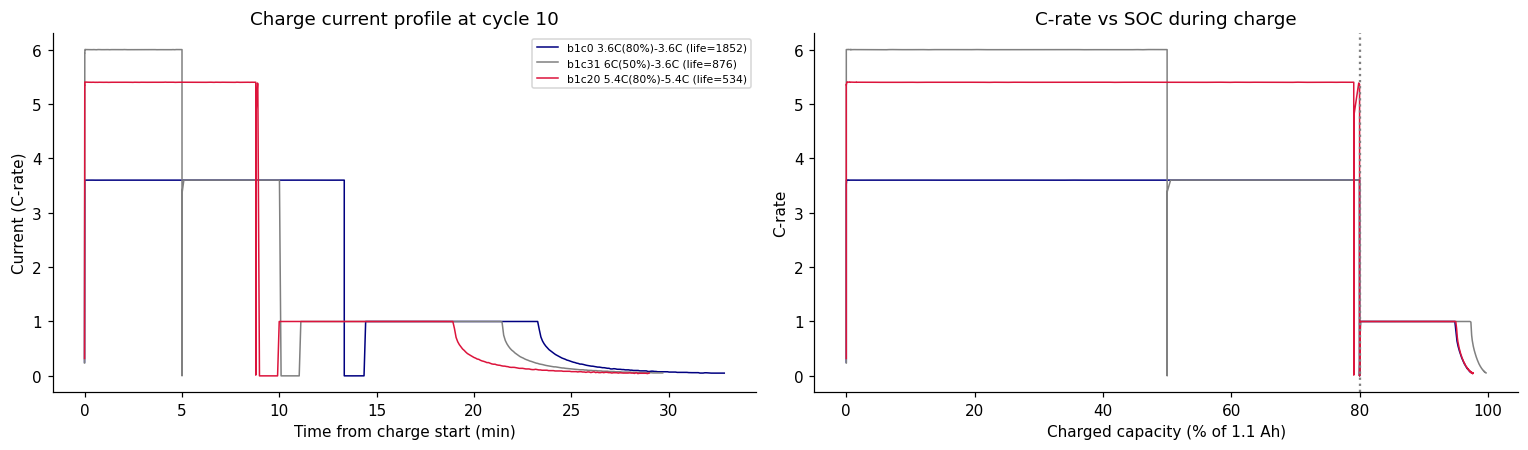

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
srt = meta.dropna(subset=['avgC']).sort_values('avgC')
for cid, col in zip([srt.index[0], srt.index[len(srt) // 2], srt.index[-1]], ['navy', 'gray', 'crimson']):
    pr = ds['profile'].get(cid)
    if pr is None or len(pr['I']) == 0:
        continue
    chg = np.where(pr['I'] > 0.05)[0]
    if len(chg) < 5:
        continue
    sl_ = slice(chg[0], chg[-1] + 1)
    lab = f'{cid} {meta.at[cid, "policy"]} (life={meta.at[cid, "cycle_life"]:.0f})'
    axes[0].plot(pr['t'][sl_] - pr['t'][chg[0]], pr['I'][sl_], color=col, lw=1, label=lab)       # I는 C-rate 단위로 저장됨
    axes[1].plot(pr['Qc'][sl_] / NOMINAL * 100, pr['I'][sl_], color=col, lw=1, label=lab)
axes[0].set(title='Charge current profile at cycle 10', xlabel='Time from charge start (min)', ylabel='Current (C-rate)'); axes[0].legend(fontsize=7)
axes[1].set(title='C-rate vs SOC during charge', xlabel='Charged capacity (% of 1.1 Ah)', ylabel='C-rate'); axes[1].axvline(80, color='gray', ls=':')
plt.tight_layout(); R.savefig('Q4_b_current_profile')


[Spearman ρ : 충전 조건 · 온도 · 열화 속도 · 수명 (전체)]
                 C1       Q1      C2      avgC  CT_early  Tmax_early  fade_0_20      knee  log_life
C1                1    -0.52 -0.5743  -0.05058   0.08996      0.1847     0.1478   0.09085  -0.00061
Q1            -0.52        1 -0.0498  -0.01469  -0.06524      -0.321    -0.1339   0.08491    0.1515
C2          -0.5743  -0.0498       1    0.3688   -0.3154     0.04092    0.07559   -0.1654   -0.1976
avgC       -0.05058 -0.01469  0.3688         1   -0.6589     0.04384     0.1034 -0.002453   -0.1663
CT_early    0.08996 -0.06524 -0.3154   -0.6589         1     -0.1386     -0.158   -0.2901  -0.09106
Tmax_early   0.1847   -0.321 0.04092   0.04384   -0.1386           1     0.1964    0.0569  -0.04871
fade_0_20    0.1478  -0.1339 0.07559    0.1034    -0.158      0.1964          1    0.3288    0.3463
knee        0.09085  0.08491 -0.1654 -0.002453   -0.2901      0.0569     0.3288         1    0.9874
log_life   -0.00061   0.1515 -0.1976   -0.1663  -0.0910

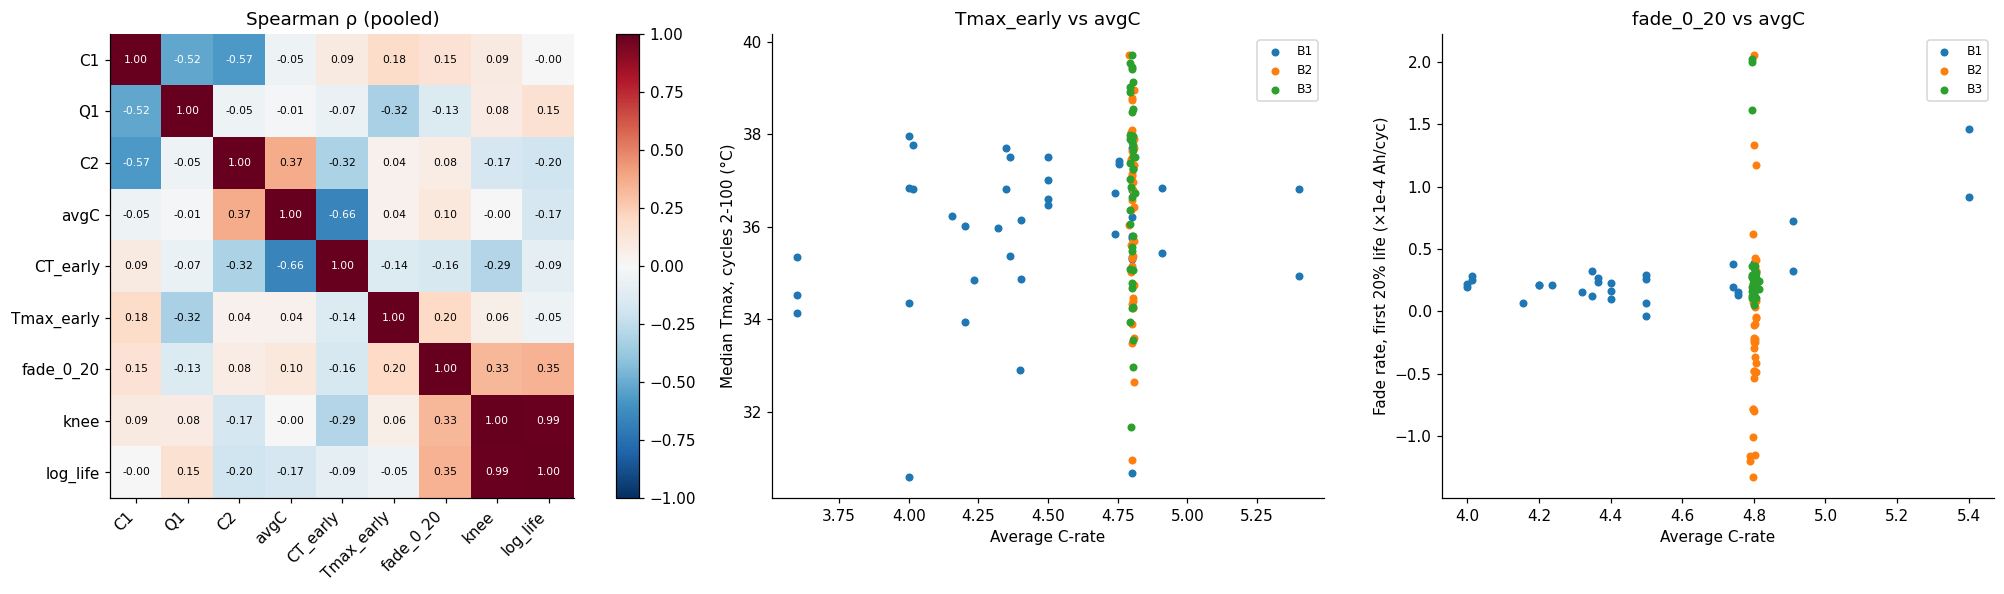


[배치별 평균 Tmax_early 중앙값] (휴지 시간 등 실험 조건 차이 확인) {'B1': 36.15, 'B2': 36.43, 'B3': 37.25}


In [ ]:
q4cols = ['C1', 'Q1', 'C2', 'avgC', 'CT_early', 'Tmax_early', 'fade_0_20', 'knee', 'log_life']
rho_mat = meta[q4cols].corr(method='spearman')
R.table(rho_mat, 'Spearman ρ : 충전 조건 · 온도 · 열화 속도 · 수명 (전체)')
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), gridspec_kw={'width_ratios': [1.5, 1, 1]})
ax = axes[0]
im = ax.imshow(rho_mat, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(q4cols))); ax.set_xticklabels(q4cols, rotation=45, ha='right'); ax.set_yticks(range(len(q4cols))); ax.set_yticklabels(q4cols)
for i in range(len(q4cols)):
    for j in range(len(q4cols)):
        v = rho_mat.iloc[i, j]; ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color='white' if abs(v) > .5 else 'black')
ax.set_title('Spearman ρ (pooled)'); plt.colorbar(im, ax=ax, fraction=.046)
for ax, (xc, yc, xl, yl) in zip(axes[1:], [('avgC', 'Tmax_early', 'Average C-rate', 'Median Tmax, cycles 2-100 (°C)'),
                                             ('avgC', 'fade_0_20', 'Average C-rate', 'Fade rate, first 20% life (×1e-4 Ah/cyc)')]):
    for b in BATCHES:
        sb = meta[meta.batch == b]; ax.scatter(sb[xc], sb[yc], color=BCOLOR[b], s=18, label=b)
    ax.set(xlabel=xl, ylabel=yl, title=f'{yc} vs {xc}'); ax.legend(fontsize=8)
plt.tight_layout(); R.savefig('Q4_c_crate_temp_fade')
R.log('\n[배치별 평균 Tmax_early 중앙값] (휴지 시간 등 실험 조건 차이 확인)', meta.groupby('batch').Tmax_early.median().round(2).to_dict())


[같은 충전 정책(구조 표기 제외)이 2개 이상 그룹에 있는 경우 (4개) : 평균 수명]
group           B1-old  B2-new  B2-old  B3-new
policy_base                                   
4.8C(80%)-4.8C     753   871.7   483.6    1588
5.2C(58%)-4C       NaN   961.7   477.8     NaN
5.6C(26%)-4.5C     NaN   991.3   448.5     NaN
6C(60%)-3C         744     NaN     400     NaN


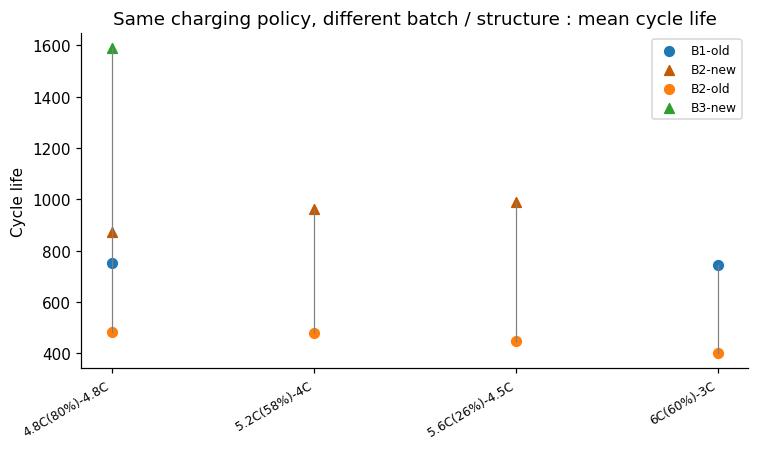

In [ ]:
meta['group'] = meta['batch'] + '-' + meta['structure']
shared = meta.groupby('policy_base').group.nunique()
shared = shared[shared >= 2].index
sp = meta[meta.policy_base.isin(shared)].groupby(['policy_base', 'group']).cycle_life.mean().unstack()
R.table(sp, f'같은 충전 정책(구조 표기 제외)이 2개 이상 그룹에 있는 경우 ({len(shared)}개) : 평균 수명')
GCOLOR = {'B1-old': BCOLOR['B1'], 'B2-old': BCOLOR['B2'], 'B2-new': '#c45a00', 'B3-new': BCOLOR['B3']}
if len(sp):
    fig, ax = plt.subplots(figsize=(max(7, len(sp) * .8), 4.2))
    for k, p in enumerate(sp.index):
        for g in sp.columns:
            if not np.isnan(sp.at[p, g]):
                ax.scatter(k, sp.at[p, g], color=GCOLOR.get(g, 'k'), s=40, marker='^' if g.endswith('new') else 'o', label=g)
        ax.plot([k, k], [np.nanmin(sp.loc[p]), np.nanmax(sp.loc[p])], color='gray', lw=.8)
    h, l = ax.get_legend_handles_labels(); u = dict(zip(l, h))
    ax.legend(u.values(), u.keys(), fontsize=8)
    ax.set_xticks(range(len(sp))); ax.set_xticklabels(sp.index, rotation=30, ha='right', fontsize=8)
    ax.set(title='Same charging policy, different batch / structure : mean cycle life', ylabel='Cycle life')
    plt.tight_layout(); R.savefig('Q4_d_same_policy_batch_effect')


[그룹(배치-구조)별 중앙값]
        cycle_life  IR_early  CT_early  Tmax_early  QD_early
group                                                       
B1-old         842   0.01666     10.92       36.15     1.082
B2-new         904   0.01497     10.04       36.97     1.092
B2-old         451   0.01663     10.17        36.4     1.099
B3-new       964.5   0.01537     10.04       37.25     1.068
  B2 old vs new — cycle_life : 451 vs 904, Mann-Whitney p=7.33e-06
  B2 old vs new — IR_early   : 0.01663 vs 0.01497, Mann-Whitney p=0.000305
  B2 old vs new — CT_early   : 10.17 vs 10.04, Mann-Whitney p=7.35e-06
  B2 old vs new — Tmax_early : 36.4 vs 36.97, Mann-Whitney p=0.934
  B2 old vs new — QD_early   : 1.099 vs 1.092, Mann-Whitney p=0.0989


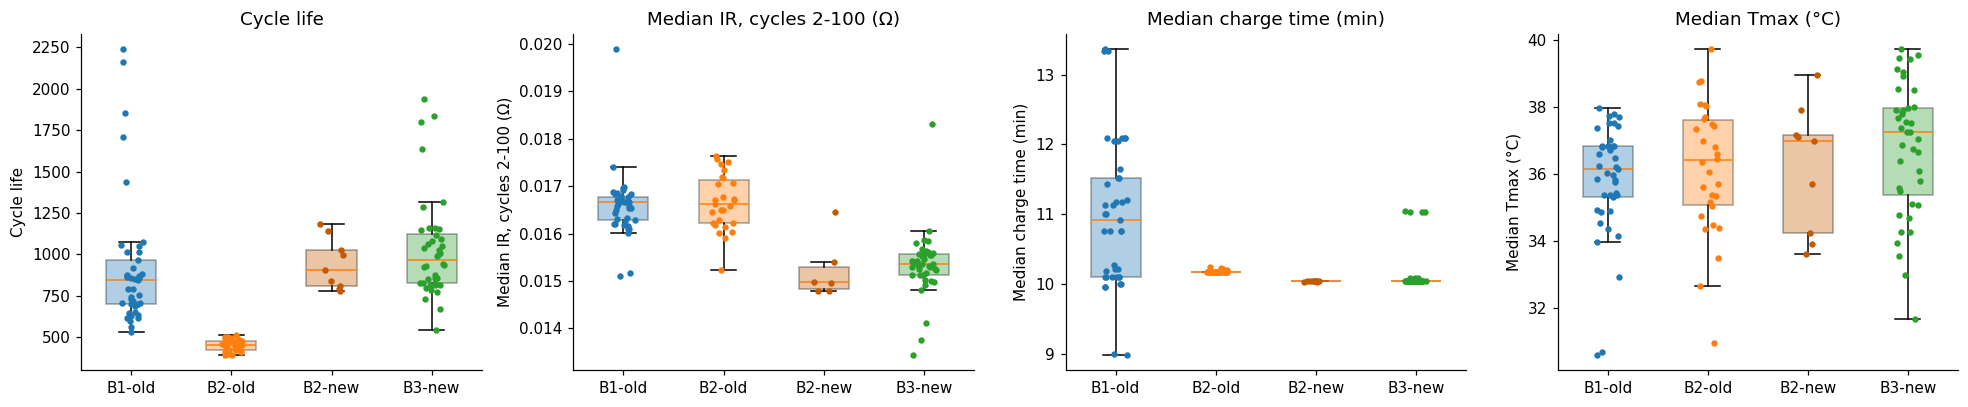

In [ ]:
# 셀 구조(newstructure) 효과 : Batch 2 안에서 old vs new 비교 (같은 배치 → 실험 시기 차이 통제)
cmp_cols = ['cycle_life', 'IR_early', 'CT_early', 'Tmax_early', 'QD_early']
R.table(meta.groupby('group')[cmp_cols].median(), '그룹(배치-구조)별 중앙값')
b2m = meta[meta.batch == 'B2']
if b2m.structure.nunique() == 2:
    for c in cmp_cols:
        o, n = b2m[b2m.structure == 'old'][c].dropna(), b2m[b2m.structure == 'new'][c].dropna()
        if len(o) > 1 and len(n) > 1:
            R.log(f'  B2 old vs new — {c:11s}: {o.median():.4g} vs {n.median():.4g}, Mann-Whitney p={stats.mannwhitneyu(o, n).pvalue:.3g}')
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
order_g = [g for g in ['B1-old', 'B2-old', 'B2-new', 'B3-new'] if g in set(meta.group)]
for ax, c, yl in zip(axes, ['cycle_life', 'IR_early', 'CT_early', 'Tmax_early'],
                     ['Cycle life', 'Median IR, cycles 2-100 (Ω)', 'Median charge time (min)', 'Median Tmax (°C)']):
    for k, g in enumerate(order_g):
        v = meta[meta.group == g][c].dropna()
        ax.boxplot(v, positions=[k], widths=.5, showfliers=False, patch_artist=True, boxprops=dict(facecolor=GCOLOR[g], alpha=.35))
        ax.scatter(np.full(len(v), k) + np.random.uniform(-.12, .12, len(v)), v, color=GCOLOR[g], s=10, zorder=3)
    ax.set_xticks(range(len(order_g))); ax.set_xticklabels(order_g); ax.set(ylabel=yl, title=yl)
plt.tight_layout(); R.savefig('Q4_e_structure_effect')

## Q5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?

**목적** : 초기 100 사이클 후보 피처 중 ① 수명과 가장 강하게 연결된 신호 ② **배치가 바뀌어도 관계가 유지되는 신호**(Batch 1 학습 → Batch 2 테스트의 핵심) ③ 서로 겹치는 피처(다중공선성)를 확인한다.

**어떻게 해결** : 논문 Supplementary Table 1 구성의 20개 피처 + 충전 정책 수치 4개 → log10(life)와 배치별 Pearson r → 부호 안정성 → 피처 간 상관 히트맵 → **VIF 전/후**.
(최종 피처 선택은 `02_feature_engineering`에서 한다.)


Q5. 상관관계 & 다중공선성

[Pearson r with log10(cycle_life) — 배치별 / 전체 (|ALL| 순)]
                      B1       B2       B3      ALL  sign_stable  min_abs_r
dq_log_var        -0.945  -0.9184  -0.8046  -0.9194         True     0.8046
dq_log_absmin    -0.9164  -0.9014  -0.8111  -0.9062         True     0.8111
dq_mean           0.8461   0.7907   0.6894    0.845         True     0.6894
dq_2V             0.6978   0.5288    0.486   0.6918         True      0.486
qd_2             0.03462  -0.2254   0.2585  -0.5221        False    0.03462
qd_int_91_100    0.02824  -0.4113   0.2585  -0.5031        False    0.02824
qd_int_2_100     0.05566  -0.1518   0.2324  -0.4919        False    0.05566
dq_skew          -0.6775  -0.1263   -0.291  -0.4807         True     0.1263
qd_100            0.2365   -0.285   0.4147  -0.4637        False     0.2365
chargetime_5       0.796  -0.9447   0.5933   0.4435        False     0.5933
avgC             -0.7757   0.3496 -0.02421  -0.4199        False    0.02421
dq_kurt      

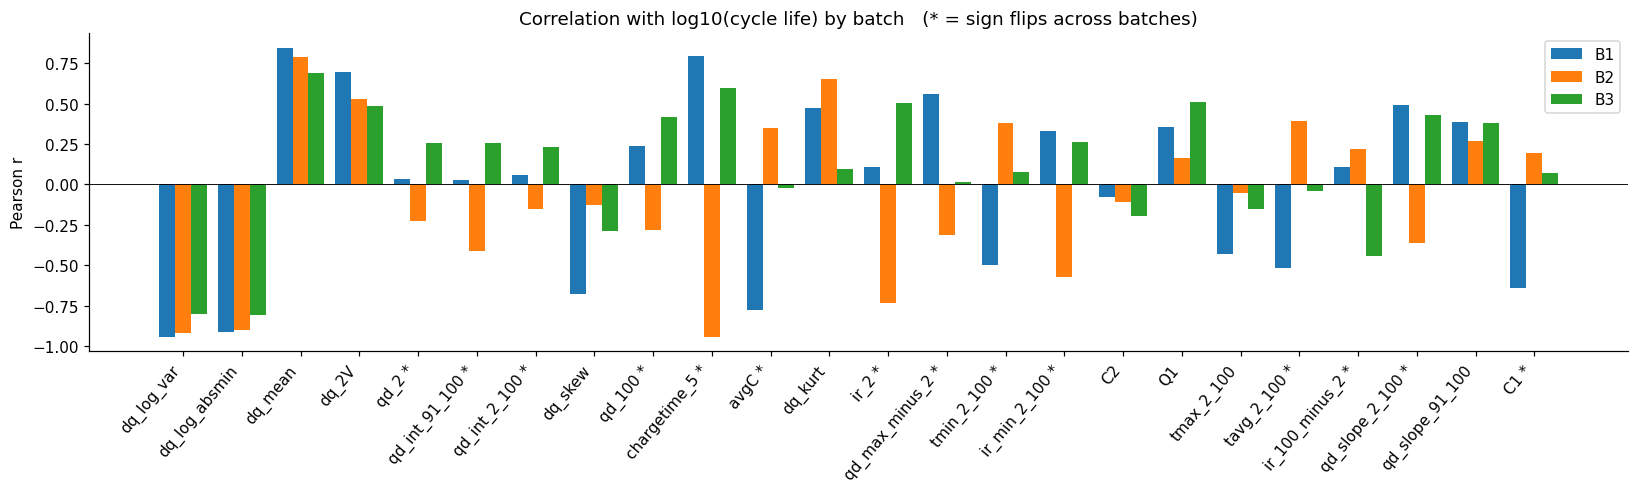

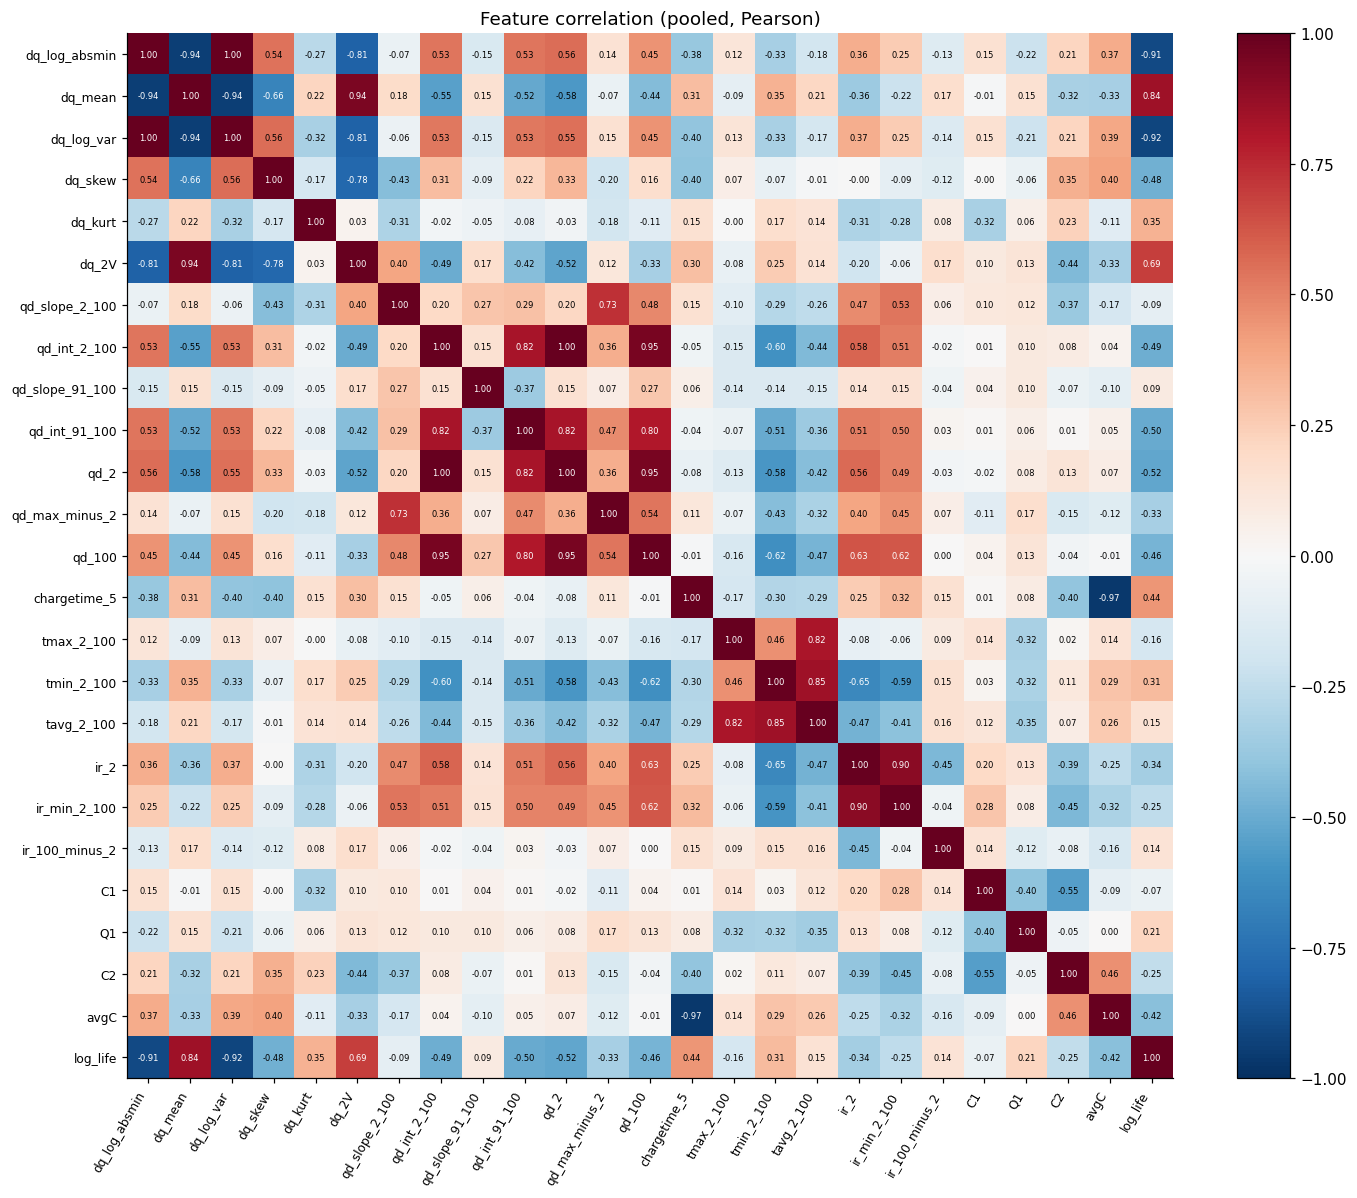


[|r| > 0.8 인 피처 쌍]
  dq_log_absmin        ~ dq_mean              r=-0.945
  dq_log_absmin        ~ dq_log_var           r=0.996
  dq_log_absmin        ~ dq_2V                r=-0.812
  dq_mean              ~ dq_log_var           r=-0.943
  dq_mean              ~ dq_2V                r=0.942
  dq_log_var           ~ dq_2V                r=-0.807
  qd_int_2_100         ~ qd_int_91_100        r=0.824
  qd_int_2_100         ~ qd_2                 r=0.996
  qd_int_2_100         ~ qd_100               r=0.953
  qd_int_91_100        ~ qd_2                 r=0.823
  qd_2                 ~ qd_100               r=0.952
  chargetime_5         ~ avgC                 r=-0.967
  tmax_2_100           ~ tavg_2_100           r=0.818
  tmin_2_100           ~ tavg_2_100           r=0.848
  ir_2                 ~ ir_min_2_100         r=0.903

[VIF (Batch 1, 24개 피처 전체)]
                      VIF
qd_int_91_100    6.27e+04
qd_100          3.062e+04
qd_slope_91_100 1.629e+04
qd_int_2_100    1.592e+04
qd_2   

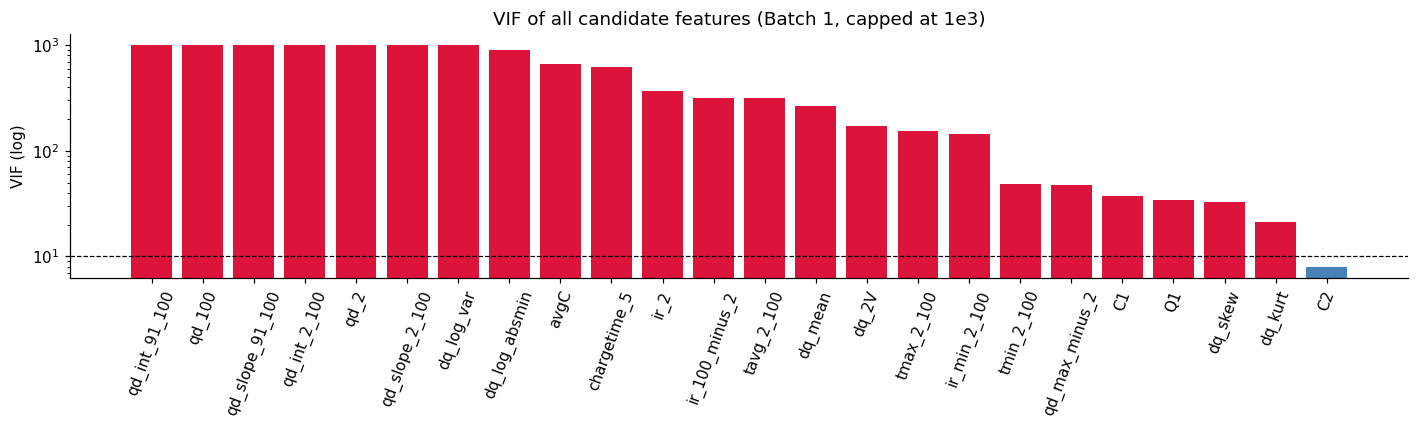

In [ ]:
R.section('Q5. 상관관계 & 다중공선성')
Rb = corr_by_batch(F, ALL_FEATS).sort_values('ALL', key=np.abs, ascending=False)
R.table(Rb, 'Pearson r with log10(cycle_life) — 배치별 / 전체 (|ALL| 순)')
fig, ax = plt.subplots(figsize=(15, 4.6))
x = np.arange(len(Rb)); w = .27
for k, b in enumerate(BATCHES):
    ax.bar(x + (k - 1) * w, Rb[b], w, color=BCOLOR[b], label=b)
ax.axhline(0, color='k', lw=.6)
ax.set_xticks(x); ax.set_xticklabels([f'{i}{"" if s_ else " *"}' for i, s_ in zip(Rb.index, Rb.sign_stable)], rotation=50, ha='right')
ax.set(title='Correlation with log10(cycle life) by batch   (* = sign flips across batches)', ylabel='Pearson r'); ax.legend()
plt.tight_layout(); R.savefig('Q5_a_corr_by_batch')

C = F[ALL_FEATS + ['log_life']].corr()
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(C, cmap='RdBu_r', vmin=-1, vmax=1)
lab = C.columns.tolist()
ax.set_xticks(range(len(lab))); ax.set_xticklabels(lab, rotation=60, ha='right', fontsize=8)
ax.set_yticks(range(len(lab))); ax.set_yticklabels(lab, fontsize=8)
for i in range(len(lab)):
    for j in range(len(lab)):
        v = C.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5.5, color='white' if abs(v) > .6 else 'black')
plt.colorbar(im, ax=ax, fraction=.046); ax.set_title('Feature correlation (pooled, Pearson)')
plt.tight_layout(); R.savefig('Q5_b_heatmap')
R.log('\n[|r| > 0.8 인 피처 쌍]')
for i, a in enumerate(ALL_FEATS):
    for b in ALL_FEATS[i + 1:]:
        if abs(C.loc[a, b]) > .8:
            R.log(f'  {a:20s} ~ {b:20s} r={C.loc[a, b]:.3f}')

usable = usable_features(F, ALL_FEATS)
train = F[F.batch == 'B1'][usable].dropna()
vb = vif(train).sort_values(ascending=False)
R.table(vb.to_frame('VIF'), f'VIF (Batch 1, {len(usable)}개 피처 전체)')
R.log(f'  VIF ≥ 10 : {int((vb >= 10).sum())}개 / {len(vb)}개')
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(vb.index, np.minimum(vb.values, 1e3), color=['crimson' if v >= 10 else 'steelblue' for v in vb.values])
ax.set_yscale('log'); ax.axhline(10, color='k', ls='--', lw=.8); ax.tick_params(axis='x', rotation=70)
ax.set(title='VIF of all candidate features (Batch 1, capped at 1e3)', ylabel='VIF (log)')
plt.tight_layout(); R.savefig('Q5_c_vif_all')

In [ ]:
R.zip_and_download()

저장 : /content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/01_EDA.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/drive/MyDrive/취준/SKALA/데이터 분석 mini Project/ess-battery-project/results/01_EDA.zip'